# 分区GSA分析

本notebook对4个气候区（HW热湿、HD热干、CW冷湿、CD冷干）分别进行：
1. 数据探索分析（EDA）
2. 全局敏感性分析（GSA）- 使用SRC、PAWN和HSIC三种方法

目标：比较不同气候区中降水和LAI对蒸散通量的相对控制强度

## 0. 导入库和设置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

# 设置绘图样式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# 创建输出目录
output_dir = Path('./importance_output/longtearm')
output_dir.mkdir(parents=True, exist_ok=True)

print("✓ 库导入完成")
print(f"✓ 输出目录: {output_dir}")

✓ 库导入完成
✓ 输出目录: importance_output/longtearm


## 1. 读取带气候区标签的数据

In [2]:
# 读取数据
classic_path = Path('./preprocessed/preprocessed_with_zones/classic_with_climate_zones_filtered_30yr_mean.csv')
lpj_path = Path('./preprocessed/preprocessed_with_zones/lpj_guess_with_climate_zones_filtered_30yr_mean.csv')

print("读取数据...")
classic_df = pd.read_csv(classic_path)
lpj_df = pd.read_csv(lpj_path)

print(f"\nCLASSIC数据: {len(classic_df):,} 行")
print(f"LPJ-GUESS数据: {len(lpj_df):,} 行")

# 查看列名
print("\nCLASSIC列名:")
print(classic_df.columns.tolist())

# 查看气候区分布
print("\nCLASSIC气候区分布:")
print(classic_df['climate_zone'].value_counts())
print("\nLPJ-GUESS气候区分布:")
print(lpj_df['climate_zone'].value_counts())

读取数据...

CLASSIC数据: 54,017 行
LPJ-GUESS数据: 53,686 行

CLASSIC列名:
['lat', 'lon', 'precipitation', 'lai', 'evapotrans', 'tran', 'evspsblveg', 'evspsblsoi', 'climate_zone', 'is_outlier']

CLASSIC气候区分布:
climate_zone
CW    20608
HW    12047
HD    11072
CD    10290
Name: count, dtype: int64

LPJ-GUESS气候区分布:
climate_zone
CW    20732
HW    12149
HD    11139
CD     9666
Name: count, dtype: int64


## 2. 定义变量和气候区

In [3]:
# 定义输入和输出变量
input_vars = ['precipitation', 'lai']
output_vars = ['evapotrans', 'tran', 'evspsblveg', 'evspsblsoi']

# 定义气候区（不包括Unknown）
climate_zones = ['HW', 'HD', 'CW', 'CD']
zone_names = {
    'HW': '热湿 (Hot-Wet)',
    'HD': '热干 (Hot-Dry)',
    'CW': '冷湿 (Cold-Wet)',
    'CD': '冷干 (Cold-Dry)'
}

# 气候区颜色
zone_colors = {
    'HW': '#FF6B6B',
    'HD': '#FFD93D',
    'CW': '#6BCB77',
    'CD': '#4D96FF'
}

print("变量定义:")
print(f"  输入变量: {input_vars}")
print(f"  输出变量: {output_vars}")
print(f"  气候区: {climate_zones}")

变量定义:
  输入变量: ['precipitation', 'lai']
  输出变量: ['evapotrans', 'tran', 'evspsblveg', 'evspsblsoi']
  气候区: ['HW', 'HD', 'CW', 'CD']


## 3. 数据探索分析（EDA）- 分气候区

### 3.1 各气候区的基本统计

In [4]:
def calculate_zone_statistics(df, model_name, zones):
    """计算各气候区的变量统计信息"""
    all_vars = input_vars + output_vars
    stats_list = []
    
    for zone in zones:
        zone_data = df[df['climate_zone'] == zone]
        if len(zone_data) == 0:
            continue
            
        for var in all_vars:
            stats_list.append({
                'Zone': zone,
                'Variable': var,
                'Count': len(zone_data),
                'Mean': zone_data[var].mean(),
                'Std': zone_data[var].std(),
                'Min': zone_data[var].min(),
                'Max': zone_data[var].max(),
                'Median': zone_data[var].median()
            })
    
    return pd.DataFrame(stats_list)

# 计算统计信息
print("计算各气候区统计信息...\n")
classic_stats = calculate_zone_statistics(classic_df, 'CLASSIC', climate_zones)
lpj_stats = calculate_zone_statistics(lpj_df, 'LPJ-GUESS', climate_zones)

print("CLASSIC模型 - 各气候区统计:")
print(classic_stats.to_string(index=False))
print("\n" + "="*80 + "\n")
print("LPJ-GUESS模型 - 各气候区统计:")
print(lpj_stats.to_string(index=False))

计算各气候区统计信息...

CLASSIC模型 - 各气候区统计:
Zone      Variable  Count        Mean        Std        Min         Max      Median
  HW precipitation  12047 1569.163619 630.183567 624.792187 3859.229688 1432.210156
  HW           lai  12047    3.876407   1.645490   0.651331    6.860609    4.039752
  HW    evapotrans  12047  916.663982 213.846194 460.440800 1519.875500  909.264470
  HW          tran  12047  387.162515 131.168704 102.738880  721.292850  376.667570
  HW    evspsblveg  12047  298.557039 162.422607  40.997500  769.292700  278.322480
  HW    evspsblsoi  12047  230.944428  91.517319  87.310710  500.243800  223.857500
  HD precipitation  11072  266.707786 239.692367   2.581250 1325.906250  213.763281
  HD           lai  11072    0.301057   0.449610   0.000000    2.855051    0.069305
  HD    evapotrans  11072  241.203102 180.647402   4.039213  758.537350  206.122480
  HD          tran  11072   48.664652  66.989872   0.000000  290.645170   15.691515
  HD    evspsblveg  11072   17.504716  27

### 3.2 可视化：各气候区的变量分布

绘制CLASSIC分布图...


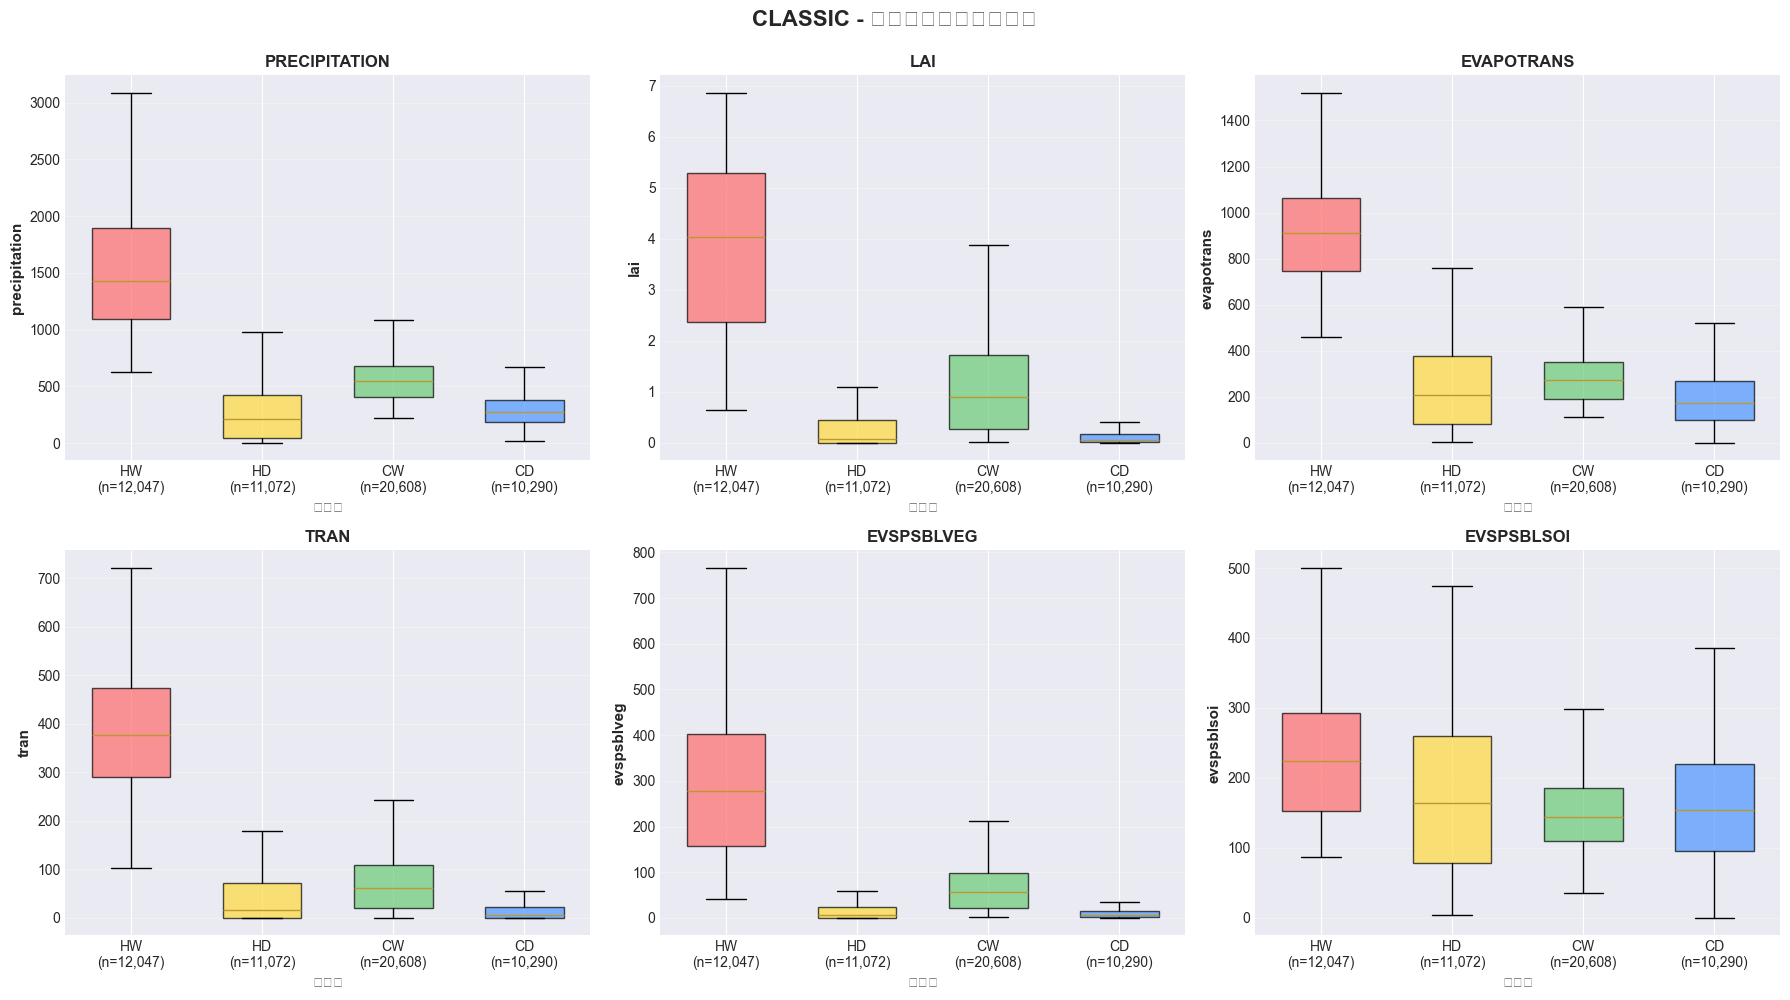

绘制LPJ-GUESS分布图...


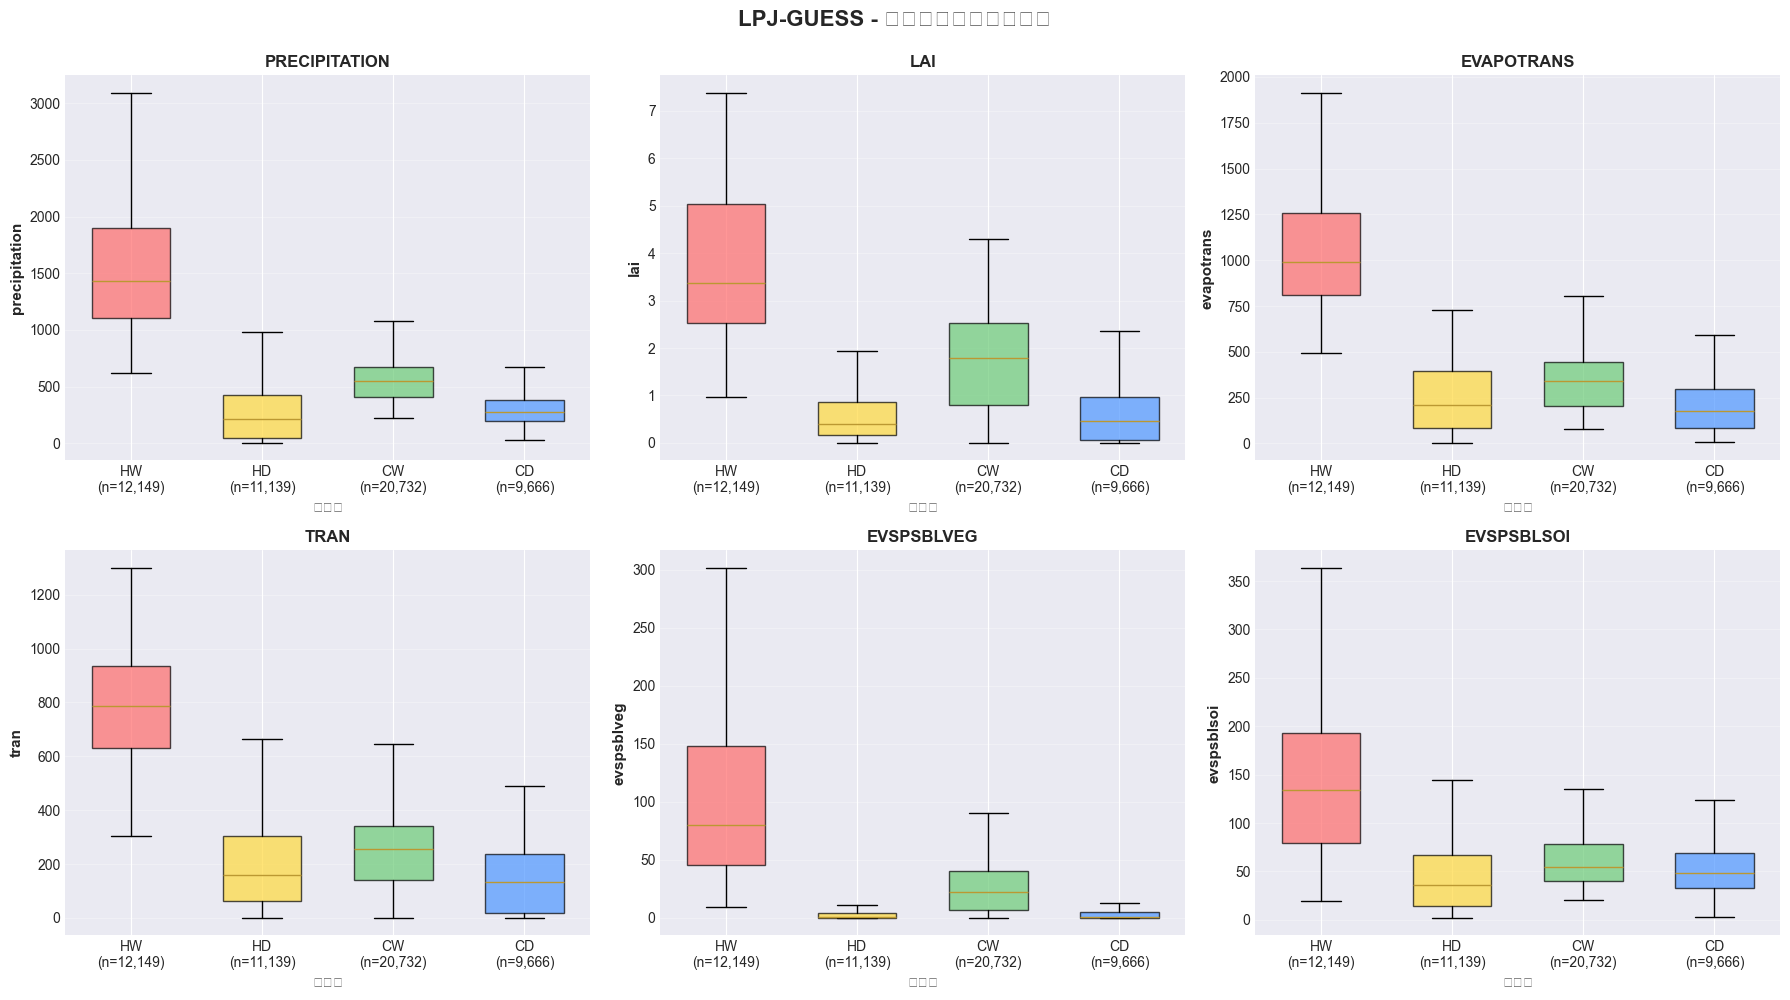

✓ 分布图已保存


In [5]:
def plot_zone_distributions(df, model_name, zones, variables):
    """绘制各气候区的变量箱线图"""
    n_vars = len(variables)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, var in enumerate(variables):
        ax = axes[i]
        
        # 准备数据
        plot_data = []
        labels = []
        colors_list = []
        
        for zone in zones:
            zone_data = df[df['climate_zone'] == zone][var].dropna()
            if len(zone_data) > 0:
                plot_data.append(zone_data)
                labels.append(f"{zone}\n(n={len(zone_data):,})")
                colors_list.append(zone_colors[zone])
        
        # 绘制箱线图
        bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
                        showfliers=False, widths=0.6)
        
        # 设置颜色
        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel(var, fontsize=11, fontweight='bold')
        ax.set_xlabel('气候区', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        ax.set_title(f'{var.upper()}', fontsize=12, fontweight='bold')
    
    # 隐藏多余的子图
    for i in range(n_vars, len(axes)):
        axes[i].axis('off')
    
    fig.suptitle(f'{model_name} - 各气候区变量分布对比', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC分布
print("绘制CLASSIC分布图...")
all_vars = input_vars + output_vars
fig1 = plot_zone_distributions(classic_df, 'CLASSIC', climate_zones, all_vars)
fig1.savefig(output_dir / 'classic_zone_distributions.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS分布
print("绘制LPJ-GUESS分布图...")
fig2 = plot_zone_distributions(lpj_df, 'LPJ-GUESS', climate_zones, all_vars)
fig2.savefig(output_dir / 'lpj_zone_distributions.png', bbox_inches='tight')
plt.show()

print("✓ 分布图已保存")


绘制CLASSIC按气候区分组的分布图...


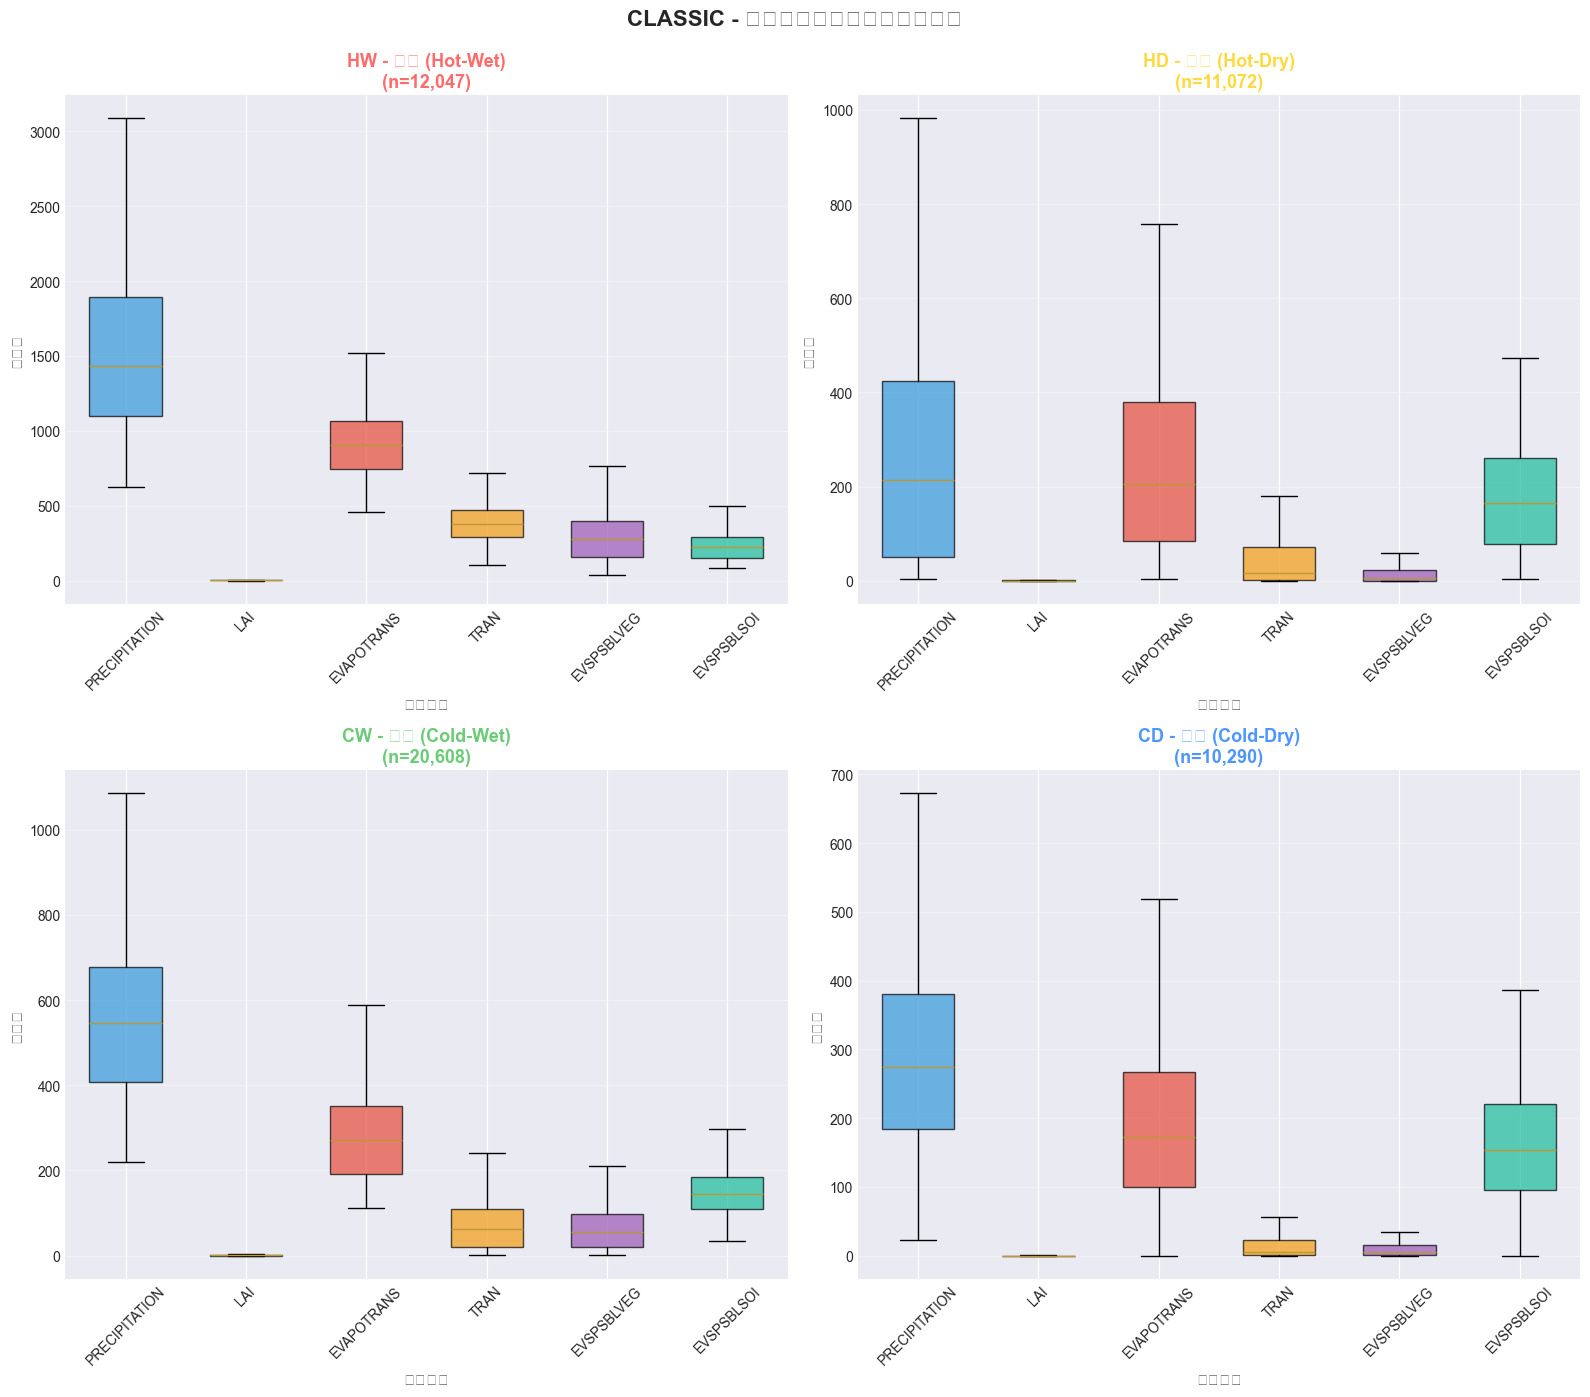

绘制LPJ-GUESS按气候区分组的分布图...


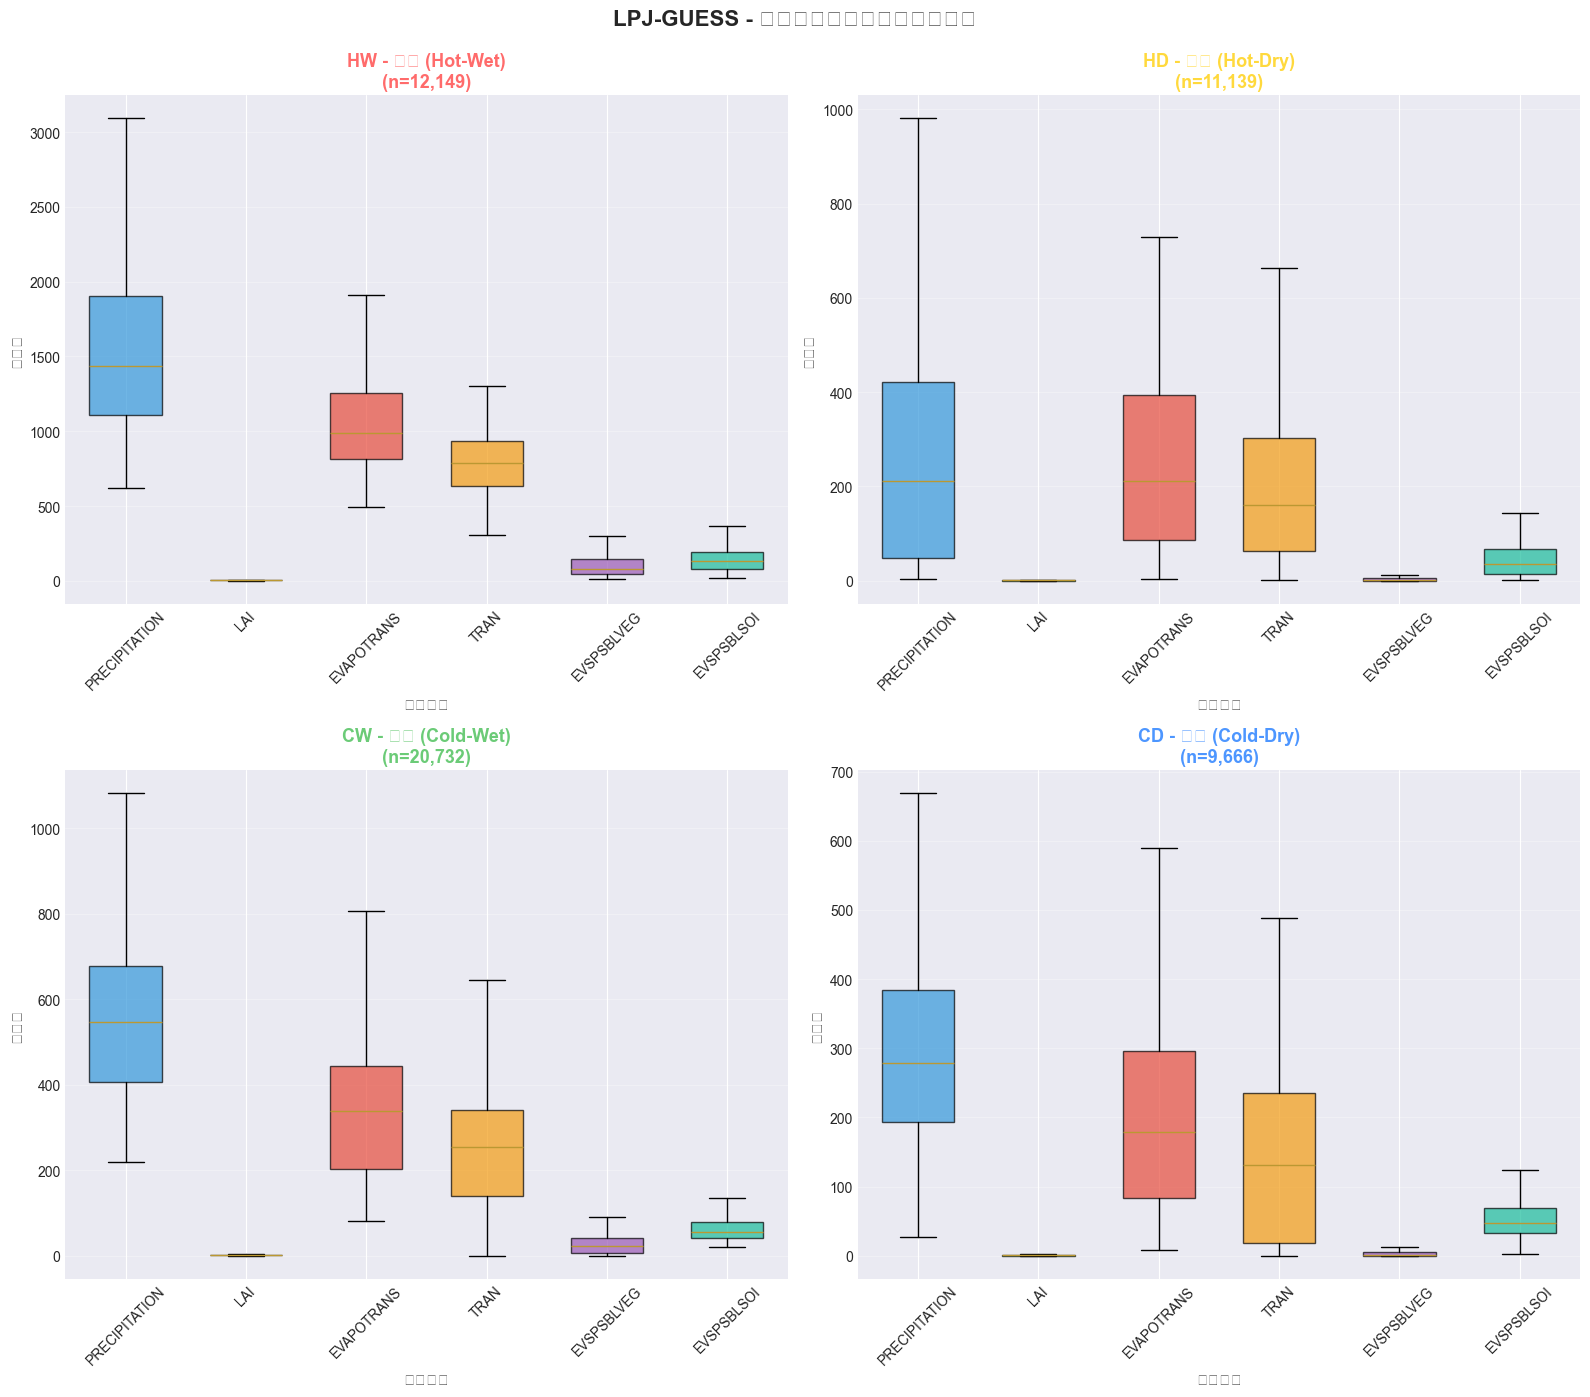

✓ 按气候区分组的分布图已保存


In [6]:
def plot_distributions_by_zone(df, model_name, zones, variables):
    """
    绘制按气候区分组的变量分布图
    
    每个子图对应一个气候区，显示该区内所有变量的箱线图对比
    """
    n_zones = len(zones)
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, zone in enumerate(zones):
        ax = axes[i]
        
        # 筛选该气候区的数据
        zone_data = df[df['climate_zone'] == zone]
        
        if len(zone_data) == 0:
            ax.text(0.5, 0.5, f'No data for {zone}',
                   ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue
        
        # 准备数据 - 所有变量在一个子图中
        plot_data = []
        labels = []
        
        for var in variables:
            var_data = zone_data[var].dropna()
            if len(var_data) > 0:
                plot_data.append(var_data)
                labels.append(var.upper())
        
        # 绘制箱线图
        bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
                        showfliers=False, widths=0.6)
        
        # 设置颜色 - 使用统一的颜色方案
        colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
        for patch, color in zip(bp['boxes'], colors[:len(plot_data)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel('变量值', fontsize=11, fontweight='bold')
        ax.set_xlabel('变量名称', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.set_title(f'{zone} - {zone_names[zone]}\n(n={len(zone_data):,})',
                    fontsize=13, fontweight='bold',
                    color=zone_colors[zone])
        
        # 旋转x轴标签以避免重叠
        ax.tick_params(axis='x', rotation=45)
    
    fig.suptitle(f'{model_name} - 按气候区分组的变量分布对比',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC - 按气候区分组
print("\n绘制CLASSIC按气候区分组的分布图...")
fig3 = plot_distributions_by_zone(classic_df, 'CLASSIC', climate_zones, all_vars)
fig3.savefig(output_dir / 'classic_distributions_by_zone.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS - 按气候区分组
print("绘制LPJ-GUESS按气候区分组的分布图...")
fig4 = plot_distributions_by_zone(lpj_df, 'LPJ-GUESS', climate_zones, all_vars)
fig4.savefig(output_dir / 'lpj_distributions_by_zone.png', bbox_inches='tight')
plt.show()

print("✓ 按气候区分组的分布图已保存")

### 3.3 相关性分析 - 分气候区

绘制CLASSIC相关性图...


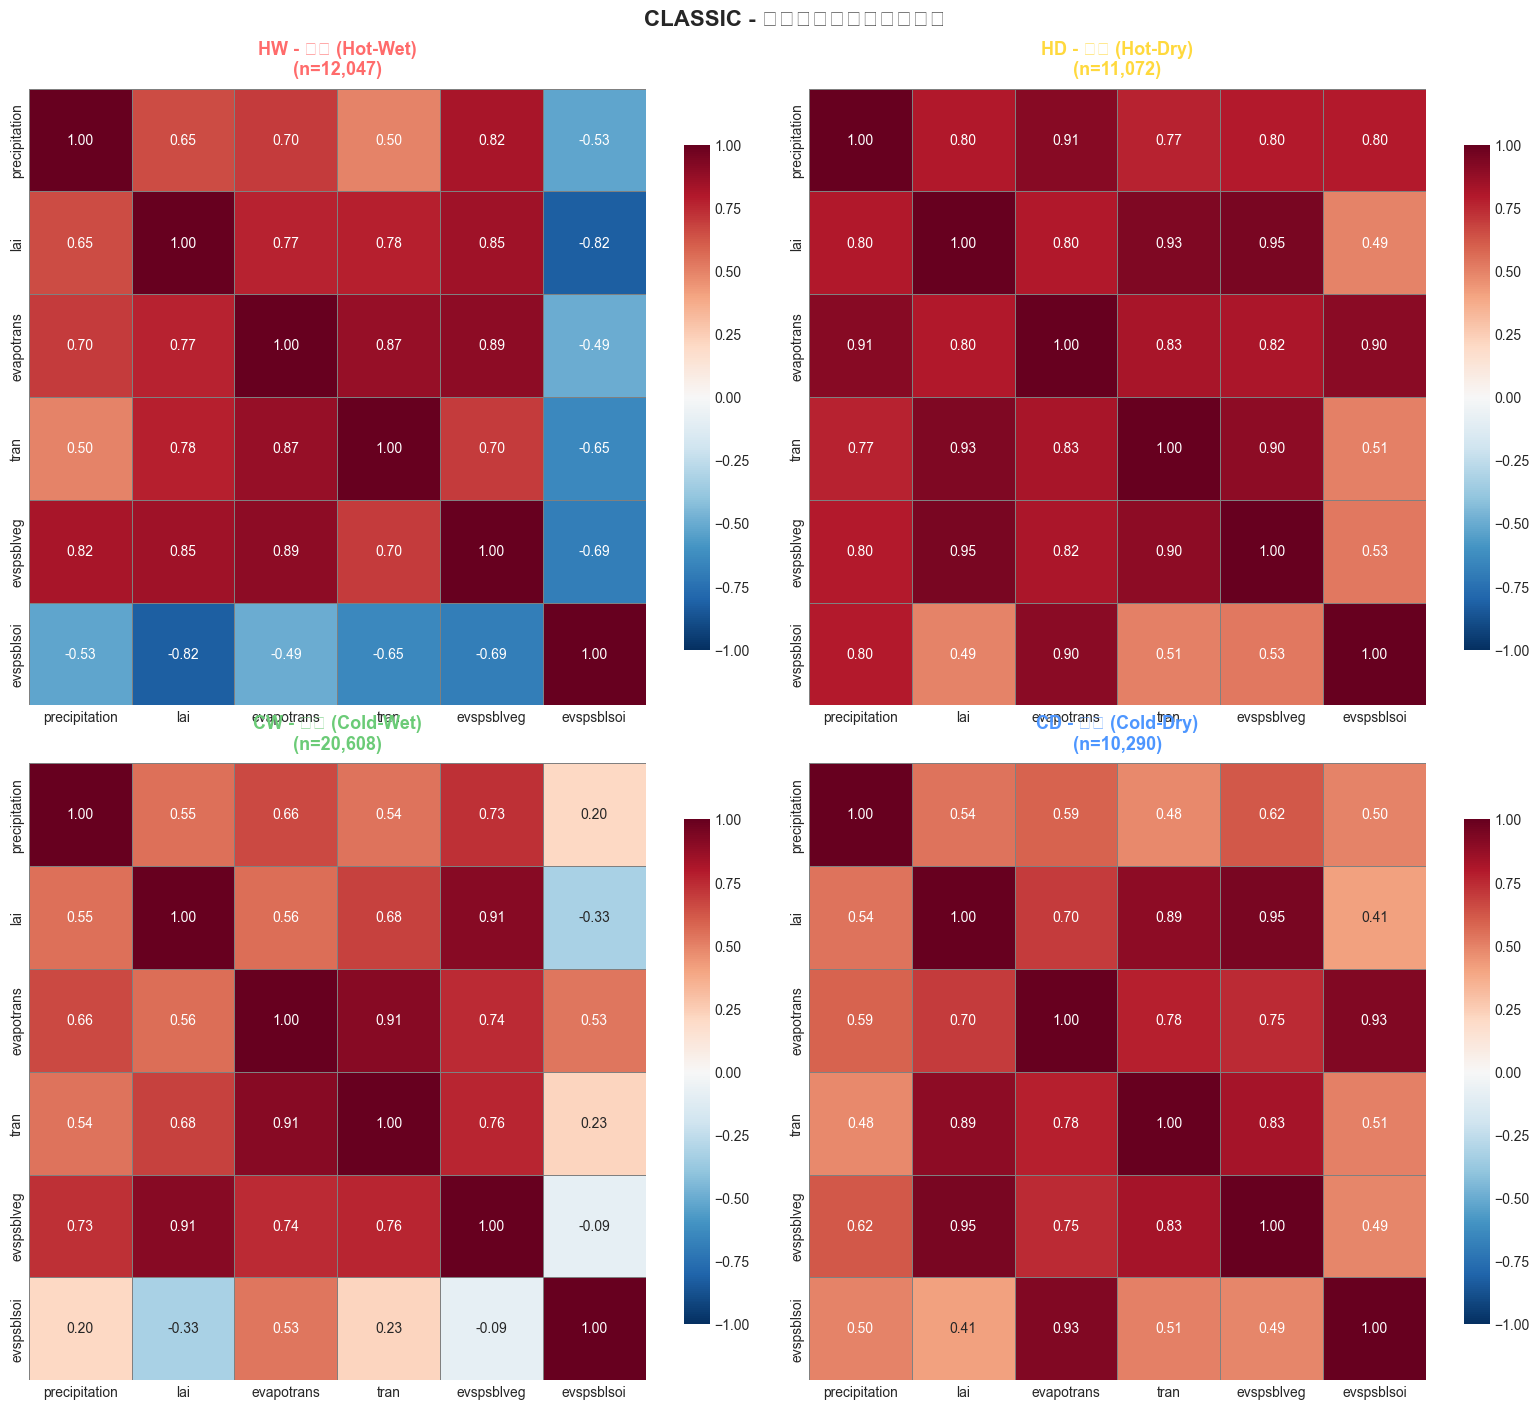

绘制LPJ-GUESS相关性图...


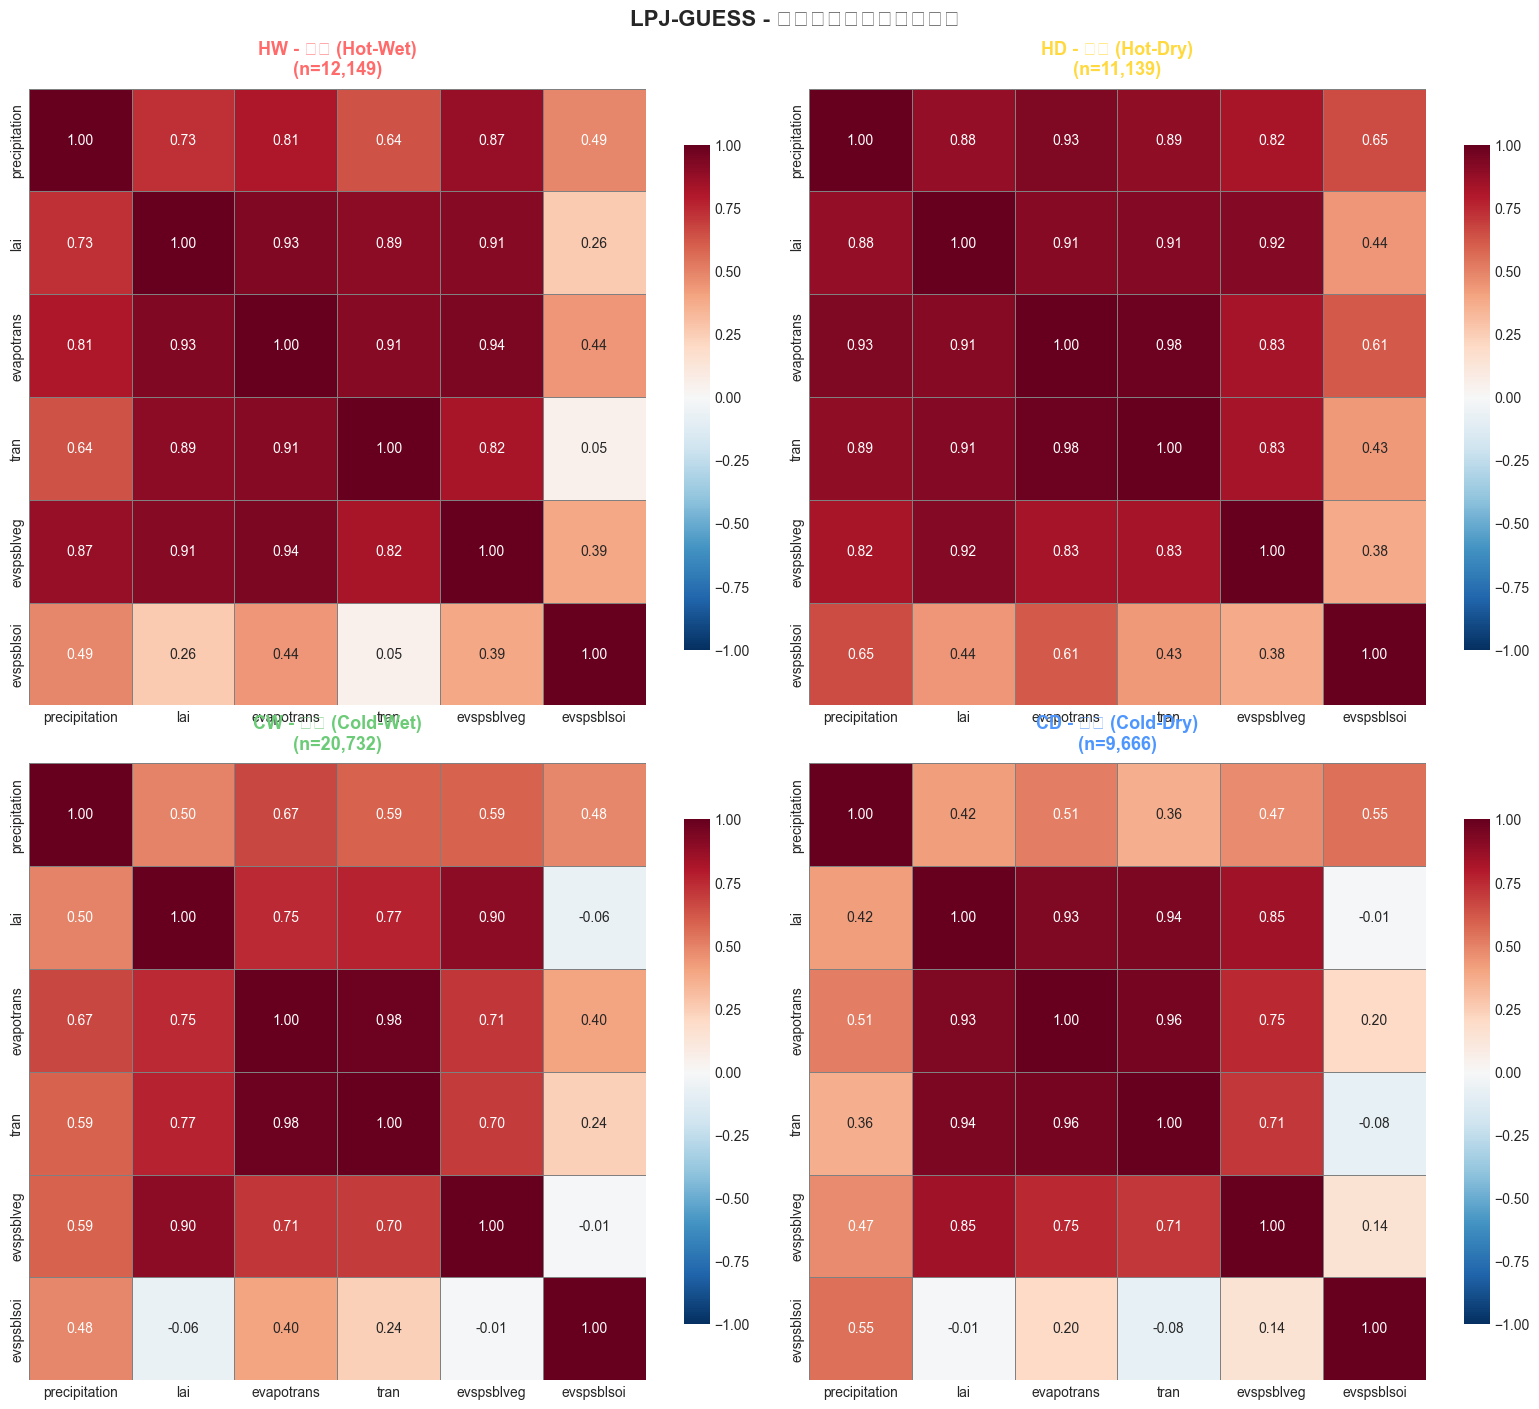

✓ 相关性图已保存


In [7]:
def plot_zone_correlations(df, model_name, zones):
    """绘制各气候区的相关性矩阵热图"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    all_vars = input_vars + output_vars
    
    for i, zone in enumerate(zones):
        ax = axes[i]
        zone_data = df[df['climate_zone'] == zone][all_vars]
        
        if len(zone_data) == 0:
            ax.text(0.5, 0.5, f'No data for {zone}', 
                   ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue
        
        # 计算相关性
        corr = zone_data.corr()
        
        # 绘制热图
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', 
                   center=0, vmin=-1, vmax=1, square=True,
                   cbar_kws={'shrink': 0.8}, ax=ax,
                   linewidths=0.5, linecolor='gray')
        
        ax.set_title(f'{zone} - {zone_names[zone]}\n(n={len(zone_data):,})', 
                    fontsize=13, fontweight='bold', pad=10,
                    color=zone_colors[zone])
    
    fig.suptitle(f'{model_name} - 各气候区变量相关性分析', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制相关性图
print("绘制CLASSIC相关性图...")
fig1 = plot_zone_correlations(classic_df, 'CLASSIC', climate_zones)
fig1.savefig(output_dir / 'classic_zone_correlations.png', bbox_inches='tight')
plt.show()

print("绘制LPJ-GUESS相关性图...")
fig2 = plot_zone_correlations(lpj_df, 'LPJ-GUESS', climate_zones)
fig2.savefig(output_dir / 'lpj_zone_correlations.png', bbox_inches='tight')
plt.show()

print("✓ 相关性图已保存")

## 4. GSA分析 - 定义方法函数

### 4.1 SRC方法

In [8]:
def calculate_src(df, input_vars, output_vars):
    """
    Calculate Standardized Regression Coefficients (SRC)
    
    Parameters:
    -----------
    df : DataFrame
        Input data
    input_vars : list
        List of input variable names
    output_vars : list
        List of output variable names
    
    Returns:
    --------
    DataFrame with SRC values and R² for each output variable
    """
    results = []
    
    # 标准化输入变量
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[input_vars].values)
    
    for output_var in output_vars:
        # 标准化输出变量
        y_scaled = StandardScaler().fit_transform(df[[output_var]]).ravel()
        
        # 线性回归
        model = LinearRegression()
        model.fit(X_scaled, y_scaled)
        
        # SRC就是回归系数
        src_values = model.coef_
        r2 = model.score(X_scaled, y_scaled)
        
        # 保存结果
        for input_var, src in zip(input_vars, src_values):
            results.append({
                'Output': output_var,
                'Input': input_var,
                'SRC': src,
                'R2': r2
            })
    
    return pd.DataFrame(results)

print("✓ SRC函数已定义")

✓ SRC函数已定义


### 4.2 PAWN方法

In [9]:
def calculate_pawn_index(df, input_var, output_var, n_bins=10):
    """
    Calculate PAWN sensitivity index
    
    Parameters:
    -----------
    df : DataFrame
        Input data
    input_var : str
        Input variable name
    output_var : str
        Output variable name
    n_bins : int
        Number of bins for conditioning
    
    Returns:
    --------
    dict with median and max KS statistics
    """
    # 无条件输出分布
    y_unconditional = df[output_var].values
    
    # 将输入变量分箱
    try:
        bins = pd.qcut(df[input_var], q=n_bins, duplicates='drop')
    except ValueError:
        # 如果分位数分箱失败，使用等宽分箱
        bins = pd.cut(df[input_var], bins=n_bins)
    
    # 计算每个bin的KS统计量
    ks_stats = []
    
    for bin_label in bins.cat.categories:
        # 条件输出分布
        y_conditional = df.loc[bins == bin_label, output_var].values
        
        if len(y_conditional) < 10:
            continue
        
        # KS检验
        ks_stat, p_value = ks_2samp(y_unconditional, y_conditional)
        ks_stats.append(ks_stat)
    
    if len(ks_stats) == 0:
        return {'median': 0, 'max': 0}
    
    return {
        'median': np.median(ks_stats),
        'max': np.max(ks_stats)
    }


def calculate_pawn_all(df, input_vars, output_vars, n_bins=10):
    """Calculate PAWN indices for all input-output combinations"""
    results = []
    
    for output_var in output_vars:
        for input_var in input_vars:
            pawn_result = calculate_pawn_index(df, input_var, output_var, n_bins)
            
            results.append({
                'Output': output_var,
                'Input': input_var,
                'PAWN_median': pawn_result['median'],
                'PAWN_max': pawn_result['max']
            })
    
    return pd.DataFrame(results)

print("✓ PAWN函数已定义")

✓ PAWN函数已定义


In [10]:
def rbf_kernel(X, Y, sigma=None):
    """
    计算RBF（高斯）核矩阵
    
    Parameters:
    -----------
    X, Y : array-like
        输入数据
    sigma : float
        核宽度参数，如果为None则使用中位数启发式
    
    Returns:
    --------
    K : ndarray
        核矩阵
    """
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    
    # 计算欧氏距离的平方
    XX = np.sum(X**2, axis=1).reshape(-1, 1)
    YY = np.sum(Y**2, axis=1).reshape(1, -1)
    distances_sq = XX + YY - 2 * np.dot(X, Y.T)
    
    # 使用中位数启发式设置sigma
    if sigma is None:
        sigma = np.median(np.sqrt(distances_sq[distances_sq > 0]))
        if sigma == 0:
            sigma = 1.0
    
    # 计算RBF核
    K = np.exp(-distances_sq / (2 * sigma**2))
    
    return K


def center_kernel_matrix(K):
    """
    中心化核矩阵
    
    Parameters:
    -----------
    K : ndarray
        核矩阵
    
    Returns:
    --------
    H_K_H : ndarray
        中心化后的核矩阵
    """
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return np.dot(np.dot(H, K), H)


def calculate_hsic(X, Y, sigma_x=None, sigma_y=None):
    """
    计算HSIC（Hilbert-Schmidt Independence Criterion）
    
    HSIC衡量两个随机变量之间的依赖关系，基于核方法。
    值越大表示依赖性越强。
    
    Parameters:
    -----------
    X, Y : array-like
        输入数据，shape (n_samples,) 或 (n_samples, n_features)
    sigma_x, sigma_y : float, optional
        核宽度参数
    
    Returns:
    --------
    hsic_value : float
        HSIC值（归一化后）
    """
    X = np.atleast_2d(X).T if X.ndim == 1 else X
    Y = np.atleast_2d(Y).T if Y.ndim == 1 else Y
    
    n = X.shape[0]
    
    # 计算核矩阵
    K = rbf_kernel(X, X, sigma_x)
    L = rbf_kernel(Y, Y, sigma_y)
    
    # 中心化核矩阵
    K_c = center_kernel_matrix(K)
    L_c = center_kernel_matrix(L)
    
    # 计算HSIC
    hsic_value = np.trace(np.dot(K_c, L_c)) / (n - 1)**2
    
    # 归一化HSIC（除以各自的核矩阵范数）
    norm_K = np.sqrt(np.trace(np.dot(K_c, K_c)) / (n - 1)**2)
    norm_L = np.sqrt(np.trace(np.dot(L_c, L_c)) / (n - 1)**2)
    
    if norm_K > 0 and norm_L > 0:
        hsic_normalized = hsic_value / (norm_K * norm_L)
    else:
        hsic_normalized = 0.0
    
    return hsic_normalized


def calculate_hsic_all(df, input_vars, output_vars, subsample_size=10000):
    """
    计算所有输入-输出组合的HSIC指数
    
    Parameters:
    -----------
    df : DataFrame
        输入数据
    input_vars : list
        输入变量列表
    output_vars : list
        输出变量列表
    subsample_size : int
        子采样大小（HSIC计算复杂度为O(n^2)，大数据集需要子采样）
    
    Returns:
    --------
    DataFrame with HSIC values
    """
    results = []
    
    # 如果数据量太大，进行子采样
    if len(df) > subsample_size:
        df_sample = df.sample(n=subsample_size, random_state=42)
    else:
        df_sample = df
    
    for output_var in output_vars:
        for input_var in input_vars:
            X = df_sample[input_var].values
            Y = df_sample[output_var].values
            
            # 移除NaN值
            mask = ~(np.isnan(X) | np.isnan(Y))
            X_clean = X[mask]
            Y_clean = Y[mask]
            
            if len(X_clean) < 10:
                hsic_value = 0.0
            else:
                hsic_value = calculate_hsic(X_clean, Y_clean)
            
            results.append({
                'Output': output_var,
                'Input': input_var,
                'HSIC': hsic_value
            })
    
    return pd.DataFrame(results)


print("✓ HSIC函数已定义")
print("  注意：HSIC是基于核方法的非参数敏感性指标")
print("  值范围：[0, 1]，越大表示依赖性越强")

✓ HSIC函数已定义
  注意：HSIC是基于核方法的非参数敏感性指标
  值范围：[0, 1]，越大表示依赖性越强


### 4.3 HSIC方法（Hilbert-Schmidt Independence Criterion）

## 5. 执行分区GSA分析

### 5.1 CLASSIC模型 - 分区GSA

In [11]:
print("="*80)
print("CLASSIC模型 - 分区GSA分析")
print("="*80)

classic_gsa_results = {}

for zone in climate_zones:
    print(f"\n处理气候区: {zone} - {zone_names[zone]}")
    
    # 筛选数据
    zone_data = classic_df[classic_df['climate_zone'] == zone].copy()
    
    if len(zone_data) < 100:
        print(f"  ⚠ 样本数量过少 (n={len(zone_data)})，跳过")
        continue
    
    print(f"  样本数量: {len(zone_data):,}")
    
    # SRC分析
    print("  计算SRC...")
    src_results = calculate_src(zone_data, input_vars, output_vars)
    
    # PAWN分析
    print("  计算PAWN...")
    pawn_results = calculate_pawn_all(zone_data, input_vars, output_vars)
    
    # HSIC分析
    print("  计算HSIC...")
    # hsic_results = calculate_hsic_all(zone_data, input_vars, output_vars)
    
    # 合并三个方法的结果
    combined = pd.merge(src_results, pawn_results, on=['Output', 'Input'])
    # combined = pd.merge(combined, hsic_results, on=['Output', 'Input'])
    combined['Zone'] = zone
    classic_gsa_results[zone] = combined
    
    print(f"  ✓ {zone} 分析完成")

# 合并所有气候区结果
classic_all_zones = pd.concat([classic_gsa_results[z] for z in classic_gsa_results.keys()], 
                               ignore_index=True)

print("\n" + "="*80)
print("CLASSIC - 所有气候区GSA结果:")
print(classic_all_zones.to_string(index=False))
print("="*80)

CLASSIC模型 - 分区GSA分析

处理气候区: HW - 热湿 (Hot-Wet)
  样本数量: 12,047
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ HW 分析完成

处理气候区: HD - 热干 (Hot-Dry)
  样本数量: 11,072
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ HD 分析完成

处理气候区: CW - 冷湿 (Cold-Wet)
  样本数量: 20,608
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ CW 分析完成

处理气候区: CD - 冷干 (Cold-Dry)
  样本数量: 10,290
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ CD 分析完成

CLASSIC - 所有气候区GSA结果:
    Output         Input       SRC       R2  PAWN_median  PAWN_max Zone
evapotrans precipitation  0.348448 0.663581     0.317285  0.568798   HW
evapotrans           lai  0.543679 0.663581     0.370403  0.642176   HW
      tran precipitation -0.018075 0.603394     0.256182  0.530380   HW
      tran           lai  0.788426 0.603394     0.418097  0.718535   HW
evspsblveg precipitation  0.468544 0.849175     0.415807  0.621998   HW
evspsblveg           lai  0.545145 0.849175     0.436450  0.771823   HW
evspsblsoi precipitation  0.008555 0.675013     0.276006  0.481584   HW
evspsblsoi           lai -0

### 5.2 LPJ-GUESS模型 - 分区GSA

In [12]:
print("="*80)
print("LPJ-GUESS模型 - 分区GSA分析")
print("="*80)

lpj_gsa_results = {}

for zone in climate_zones:
    print(f"\n处理气候区: {zone} - {zone_names[zone]}")
    
    # 筛选数据
    zone_data = lpj_df[lpj_df['climate_zone'] == zone].copy()
    
    if len(zone_data) < 100:
        print(f"  ⚠ 样本数量过少 (n={len(zone_data)})，跳过")
        continue
    
    print(f"  样本数量: {len(zone_data):,}")
    
    # SRC分析
    print("  计算SRC...")
    src_results = calculate_src(zone_data, input_vars, output_vars)
    
    # PAWN分析
    print("  计算PAWN...")
    pawn_results = calculate_pawn_all(zone_data, input_vars, output_vars)
    
    # HSIC分析
    print("  计算HSIC...")
    # hsic_results = calculate_hsic_all(zone_data, input_vars, output_vars)
    
    # 合并三个方法的结果
    combined = pd.merge(src_results, pawn_results, on=['Output', 'Input'])
    # combined = pd.merge(combined, hsic_results, on=['Output', 'Input'])
    combined['Zone'] = zone
    lpj_gsa_results[zone] = combined
    
    print(f"  ✓ {zone} 分析完成")

# 合并所有气候区结果
lpj_all_zones = pd.concat([lpj_gsa_results[z] for z in lpj_gsa_results.keys()], 
                           ignore_index=True)

print("\n" + "="*80)
print("LPJ-GUESS - 所有气候区GSA结果:")
print(lpj_all_zones.to_string(index=False))
print("="*80)

LPJ-GUESS模型 - 分区GSA分析

处理气候区: HW - 热湿 (Hot-Wet)
  样本数量: 12,149
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ HW 分析完成

处理气候区: HD - 热干 (Hot-Dry)
  样本数量: 11,139
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ HD 分析完成

处理气候区: CW - 冷湿 (Cold-Wet)
  样本数量: 20,732
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ CW 分析完成

处理气候区: CD - 冷干 (Cold-Dry)
  样本数量: 9,666
  计算SRC...
  计算PAWN...
  计算HSIC...
  ✓ CD 分析完成

LPJ-GUESS - 所有气候区GSA结果:
    Output         Input       SRC       R2  PAWN_median  PAWN_max Zone
evapotrans precipitation  0.278826 0.894772     0.380042  0.642202   HW
evapotrans           lai  0.722053 0.894772     0.492516  0.758997   HW
      tran precipitation -0.045644 0.800785     0.294732  0.503346   HW
      tran           lai  0.927846 0.800785     0.452515  0.766074   HW
evspsblveg precipitation  0.429927 0.917818     0.427782  0.675286   HW
evspsblveg           lai  0.596799 0.917818     0.516509  0.763933   HW
evspsblsoi precipitation  0.644614 0.260435     0.188839  0.411081   HW
evspsblsoi           lai

## 6. 结果可视化

### 6.1 SRC结果对比 - 分气候区

绘制CLASSIC SRC对比图...


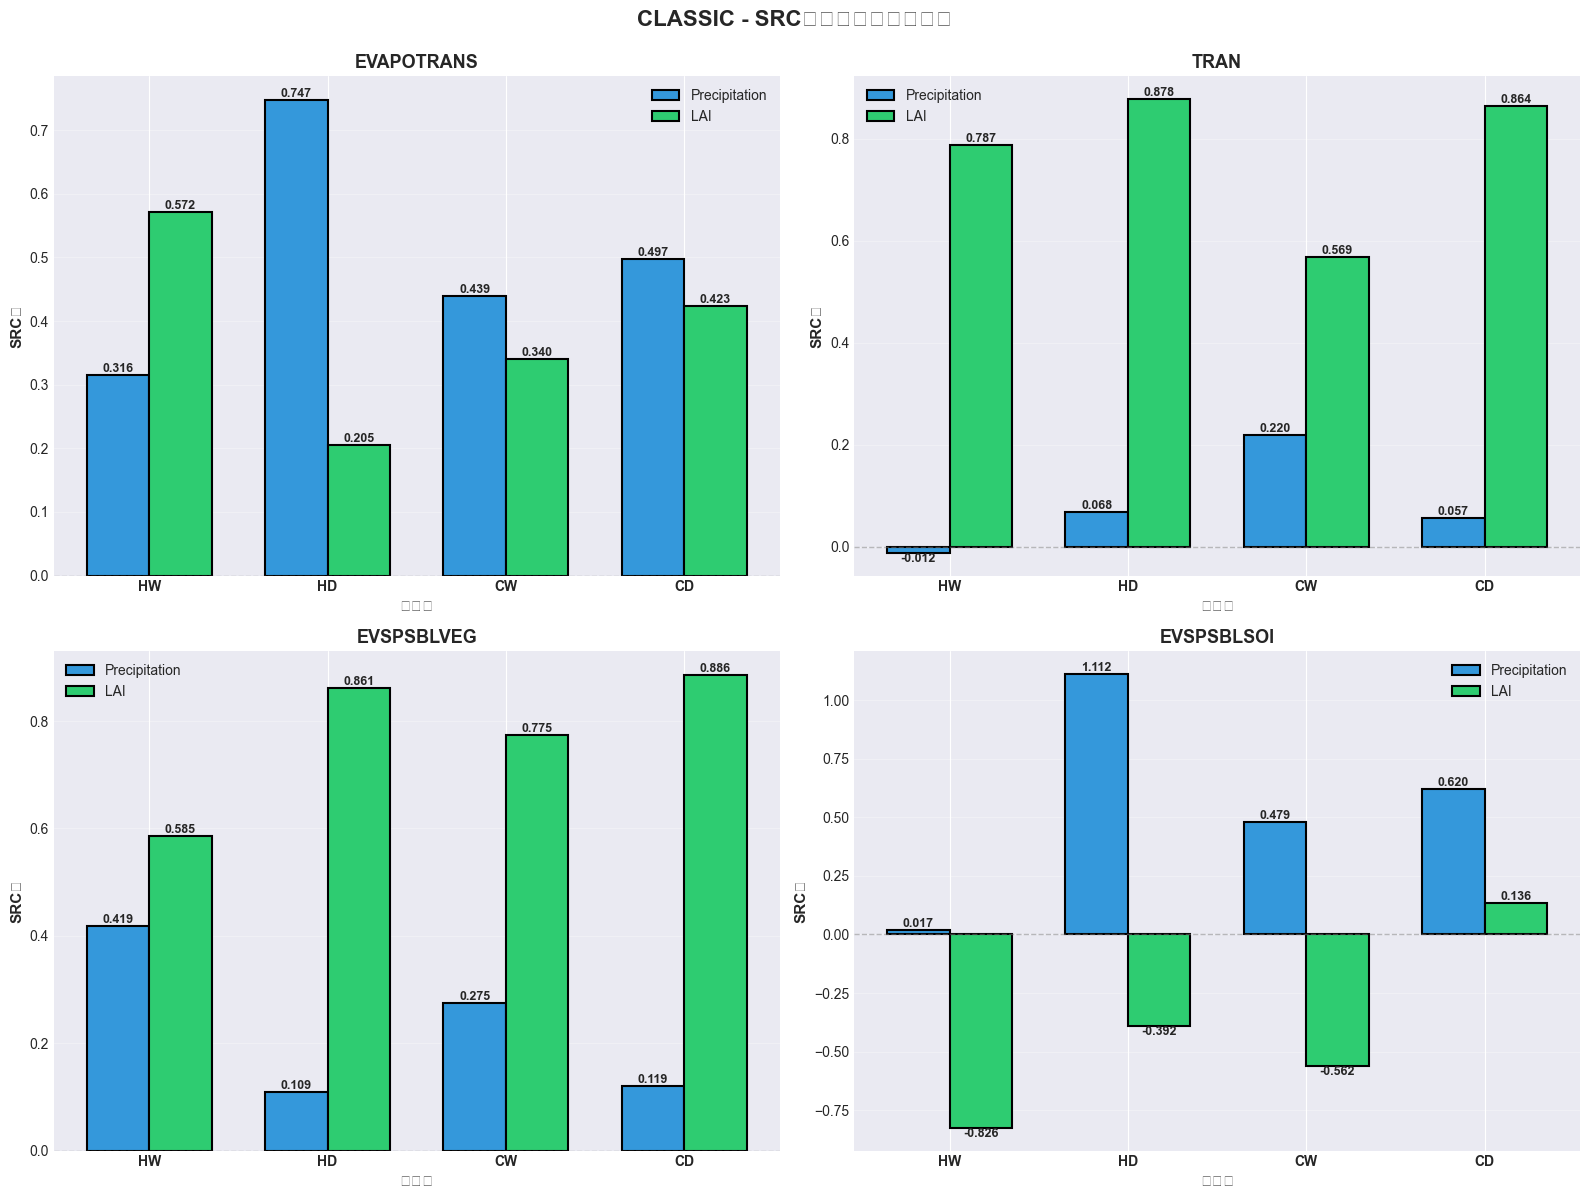

绘制LPJ-GUESS SRC对比图...


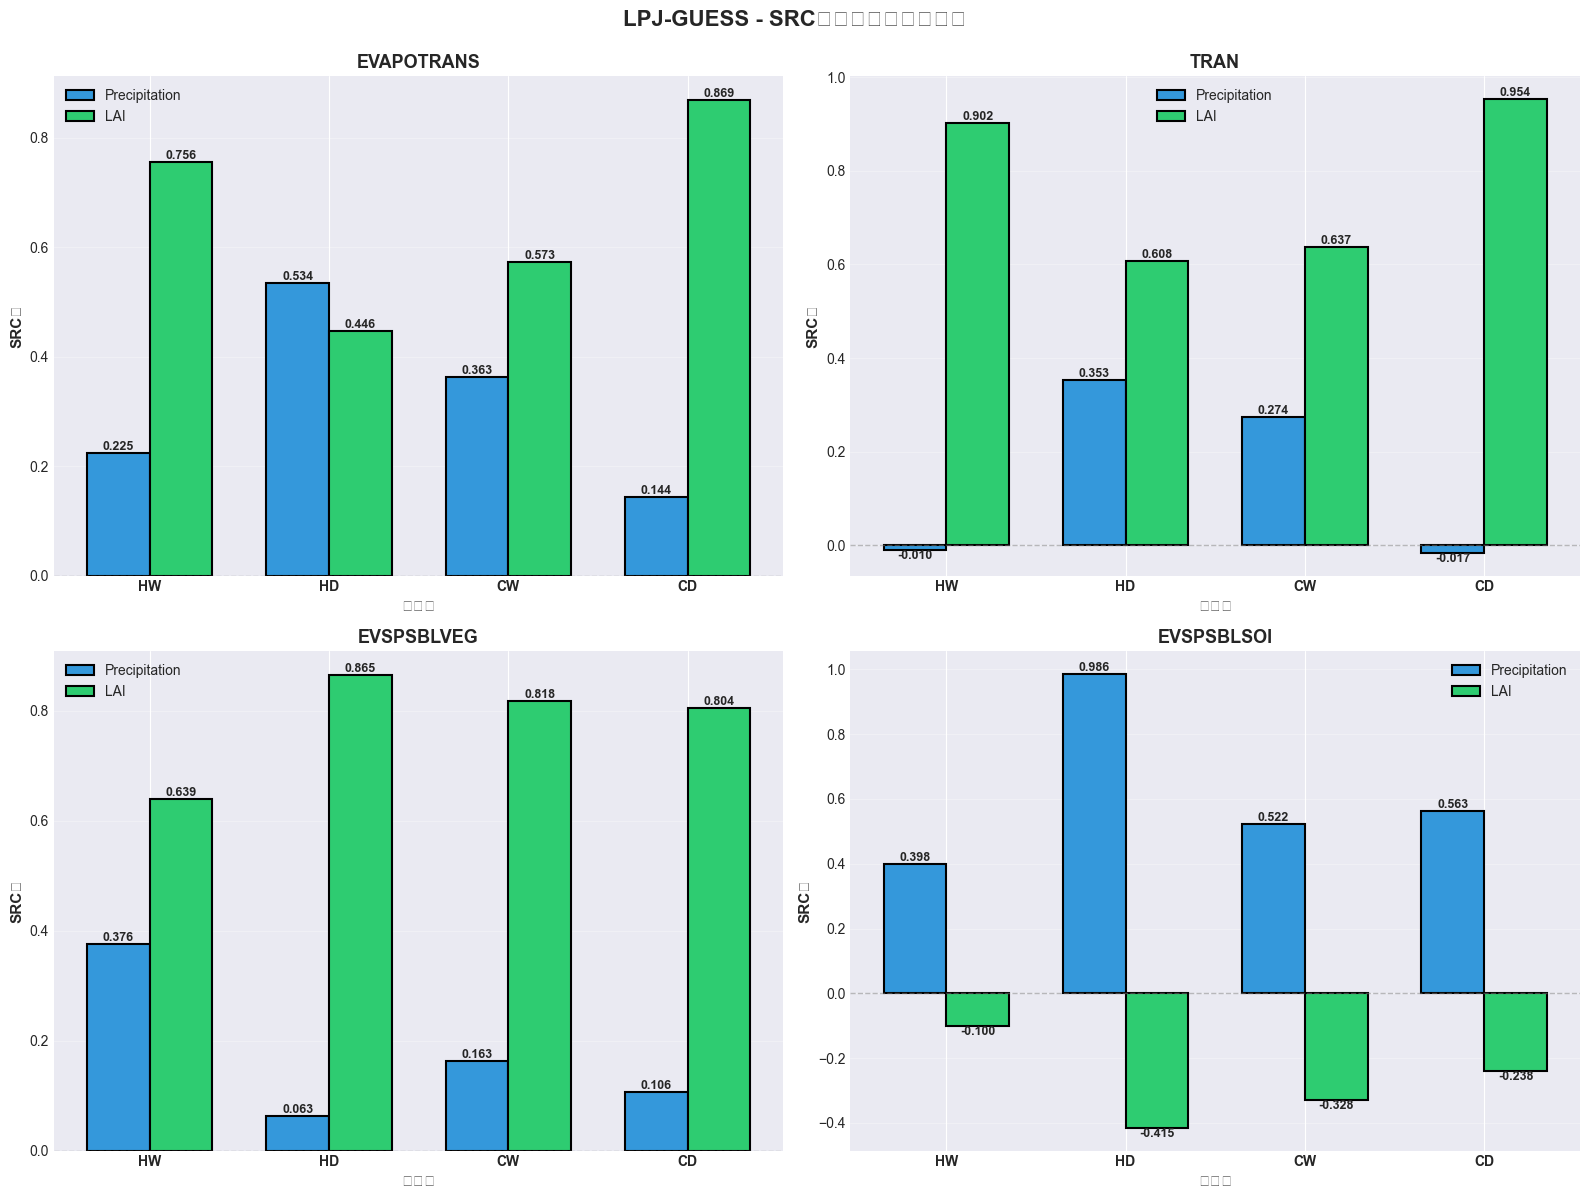

✓ SRC对比图已保存


In [14]:
def plot_src_by_zone(df, model_name, zones, output_vars):
    """绘制各气候区的SRC对比图"""
    n_outputs = len(output_vars)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, output_var in enumerate(output_vars):
        ax = axes[i]
        
        # 筛选该输出变量的数据
        data = df[df['Output'] == output_var]
        
        # 准备绘图数据
        x = np.arange(len(zones))
        width = 0.35
        
        precip_src = []
        lai_src = []
        
        for zone in zones:
            zone_data = data[data['Zone'] == zone]
            p_src = zone_data[zone_data['Input'] == 'precipitation']['SRC'].values
            l_src = zone_data[zone_data['Input'] == 'lai']['SRC'].values
            
            precip_src.append(p_src[0] if len(p_src) > 0 else 0)
            lai_src.append(l_src[0] if len(l_src) > 0 else 0)
        
        # 绘制柱状图
        bars1 = ax.bar(x - width/2, precip_src, width, label='Precipitation',
                       color='#3498db', edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x + width/2, lai_src, width, label='LAI',
                       color='#2ecc71', edgecolor='black', linewidth=1.5)
        
        # 添加数值标签
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom' if height >= 0 else 'top',
                       fontsize=9, fontweight='bold')
        
        ax.set_xlabel('气候区', fontsize=11, fontweight='bold')
        ax.set_ylabel('SRC值', fontsize=11, fontweight='bold')
        ax.set_title(f'{output_var.upper()}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(zones, fontsize=10, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.legend(fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle(f'{model_name} - SRC分析：各气候区对比', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC SRC
print("绘制CLASSIC SRC对比图...")
fig1 = plot_src_by_zone(classic_all_zones, 'CLASSIC', climate_zones, output_vars)
# fig1.savefig(output_dir / 'classic_src_by_zone.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS SRC
print("绘制LPJ-GUESS SRC对比图...")
fig2 = plot_src_by_zone(lpj_all_zones, 'LPJ-GUESS', climate_zones, output_vars)
# fig2.savefig(output_dir / 'lpj_src_by_zone.png', bbox_inches='tight')
plt.show()

print("✓ SRC对比图已保存")

### 6.2 PAWN结果对比 - 分气候区

绘制CLASSIC PAWN对比图...


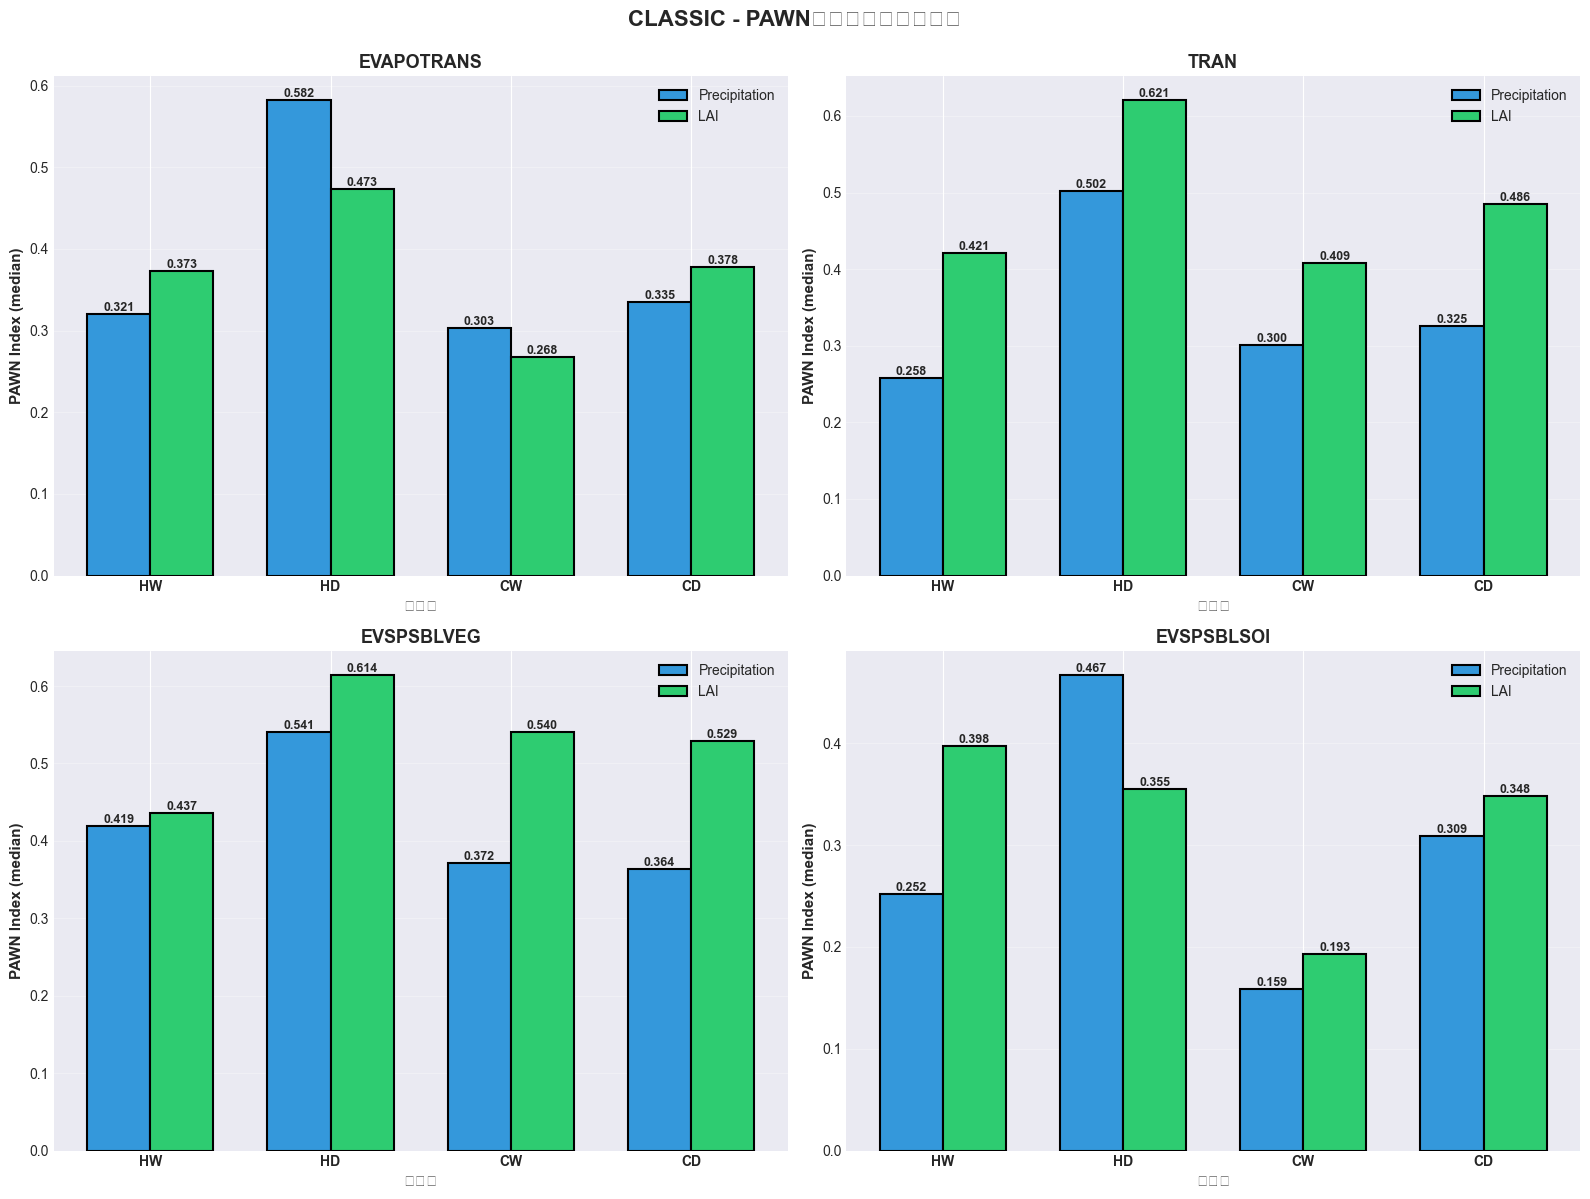

绘制LPJ-GUESS PAWN对比图...


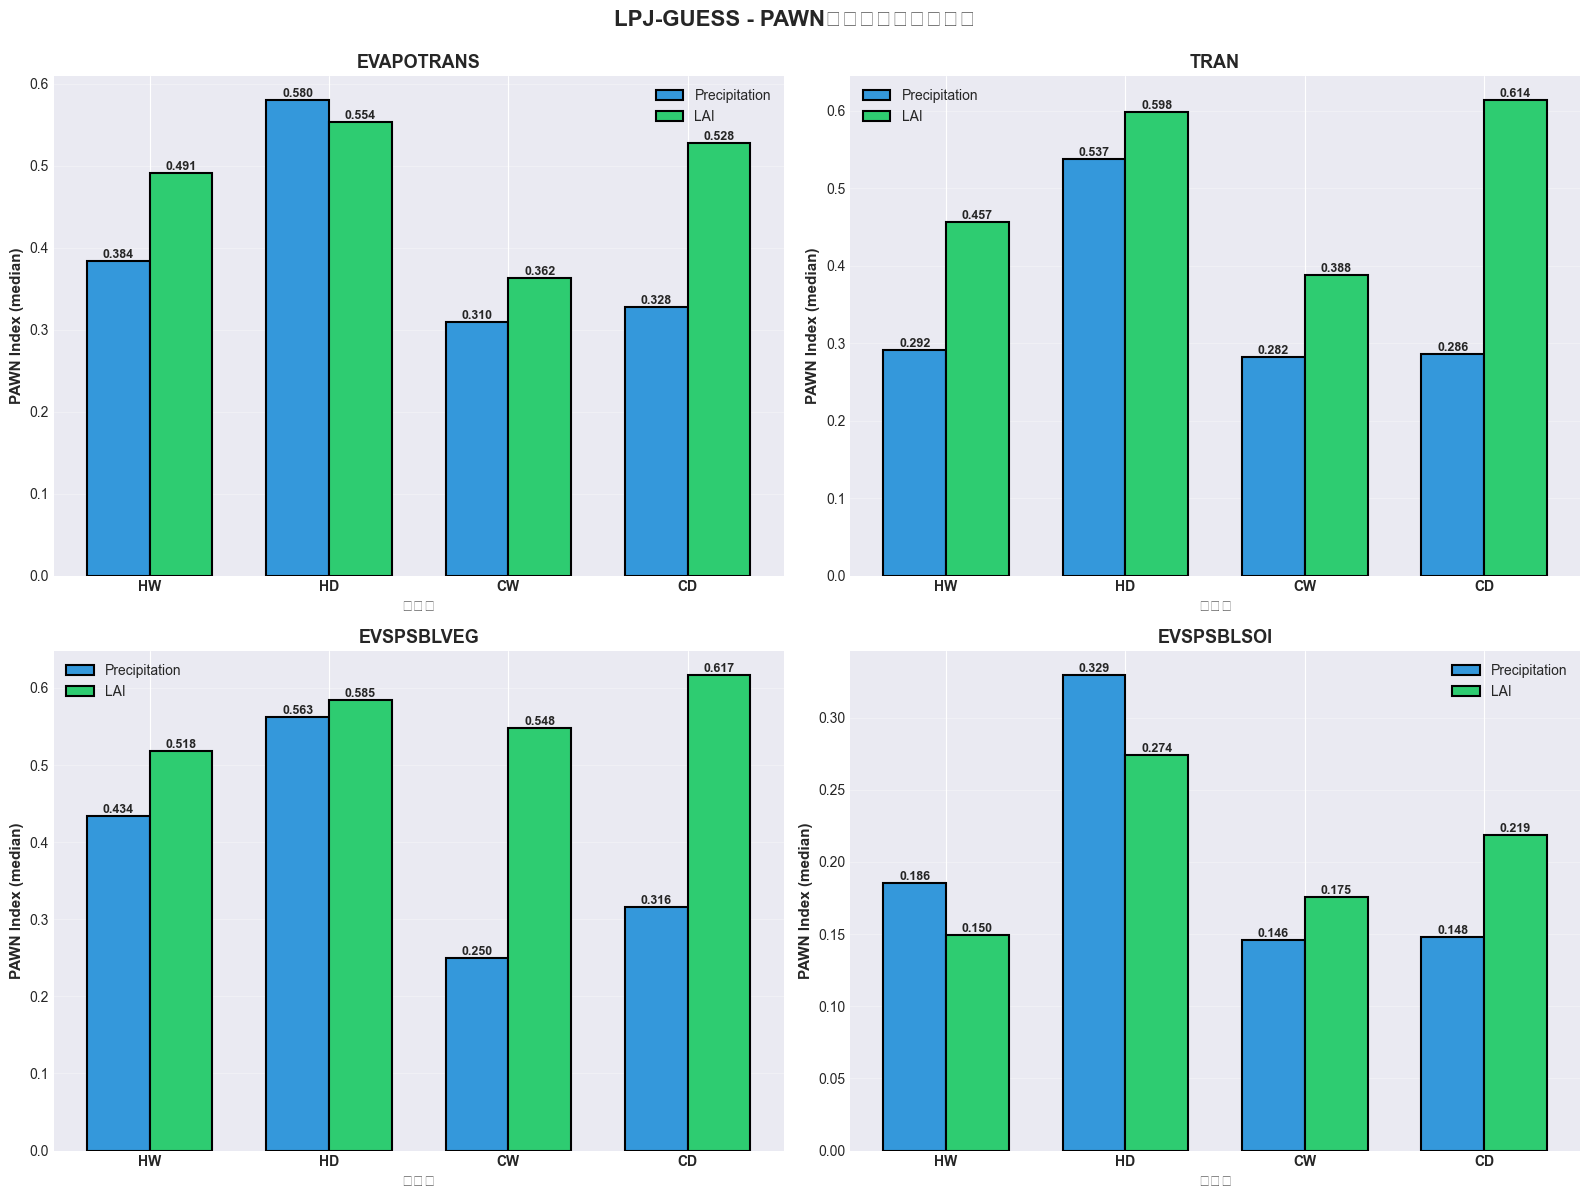

✓ PAWN对比图已保存


In [15]:
def plot_pawn_by_zone(df, model_name, zones, output_vars):
    """绘制各气候区的PAWN对比图（使用median值）"""
    n_outputs = len(output_vars)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, output_var in enumerate(output_vars):
        ax = axes[i]
        
        # 筛选该输出变量的数据
        data = df[df['Output'] == output_var]
        
        # 准备绘图数据
        x = np.arange(len(zones))
        width = 0.35
        
        precip_pawn = []
        lai_pawn = []
        
        for zone in zones:
            zone_data = data[data['Zone'] == zone]
            p_pawn = zone_data[zone_data['Input'] == 'precipitation']['PAWN_median'].values
            l_pawn = zone_data[zone_data['Input'] == 'lai']['PAWN_median'].values
            
            precip_pawn.append(p_pawn[0] if len(p_pawn) > 0 else 0)
            lai_pawn.append(l_pawn[0] if len(l_pawn) > 0 else 0)
        
        # 绘制柱状图
        bars1 = ax.bar(x - width/2, precip_pawn, width, label='Precipitation',
                       color='#3498db', edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x + width/2, lai_pawn, width, label='LAI',
                       color='#2ecc71', edgecolor='black', linewidth=1.5)
        
        # 添加数值标签
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom',
                       fontsize=9, fontweight='bold')
        
        ax.set_xlabel('气候区', fontsize=11, fontweight='bold')
        ax.set_ylabel('PAWN Index (median)', fontsize=11, fontweight='bold')
        ax.set_title(f'{output_var.upper()}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(zones, fontsize=10, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle(f'{model_name} - PAWN分析：各气候区对比', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC PAWN
print("绘制CLASSIC PAWN对比图...")
fig1 = plot_pawn_by_zone(classic_all_zones, 'CLASSIC', climate_zones, output_vars)
# fig1.savefig(output_dir / 'classic_pawn_by_zone.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS PAWN
print("绘制LPJ-GUESS PAWN对比图...")
fig2 = plot_pawn_by_zone(lpj_all_zones, 'LPJ-GUESS', climate_zones, output_vars)
# fig2.savefig(output_dir / 'lpj_pawn_by_zone.png', bbox_inches='tight')
plt.show()

print("✓ PAWN对比图已保存")

### 6.3 HSIC结果对比 - 分气候区

绘制CLASSIC HSIC对比图...


KeyError: 'HSIC'

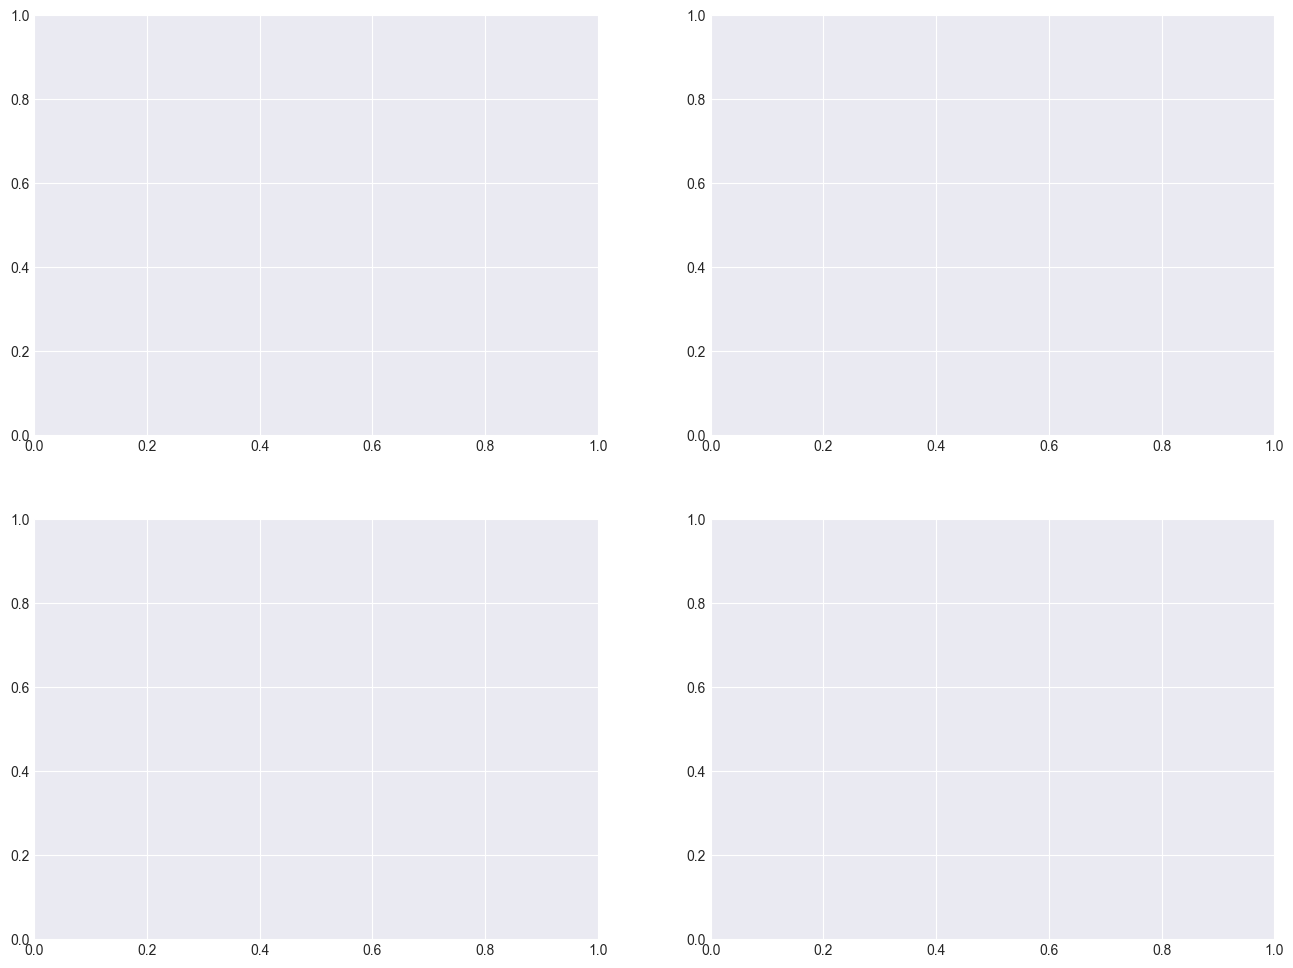

In [13]:
def plot_hsic_by_zone(df, model_name, zones, output_vars):
    """绘制各气候区的HSIC对比图"""
    n_outputs = len(output_vars)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, output_var in enumerate(output_vars):
        ax = axes[i]
        
        # 筛选该输出变量的数据
        data = df[df['Output'] == output_var]
        
        # 准备绘图数据
        x = np.arange(len(zones))
        width = 0.35
        
        precip_hsic = []
        lai_hsic = []
        
        for zone in zones:
            zone_data = data[data['Zone'] == zone]
            p_hsic = zone_data[zone_data['Input'] == 'precipitation']['HSIC'].values
            l_hsic = zone_data[zone_data['Input'] == 'lai']['HSIC'].values
            
            precip_hsic.append(p_hsic[0] if len(p_hsic) > 0 else 0)
            lai_hsic.append(l_hsic[0] if len(l_hsic) > 0 else 0)
        
        # 绘制柱状图
        bars1 = ax.bar(x - width/2, precip_hsic, width, label='Precipitation',
                       color='#3498db', edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x + width/2, lai_hsic, width, label='LAI',
                       color='#2ecc71', edgecolor='black', linewidth=1.5)
        
        # 添加数值标签
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom',
                       fontsize=9, fontweight='bold')
        
        ax.set_xlabel('气候区', fontsize=11, fontweight='bold')
        ax.set_ylabel('HSIC值', fontsize=11, fontweight='bold')
        ax.set_title(f'{output_var.upper()}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(zones, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1)  # HSIC值范围[0, 1]
        ax.legend(fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle(f'{model_name} - HSIC分析：各气候区对比', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC HSIC
print("绘制CLASSIC HSIC对比图...")
fig1 = plot_hsic_by_zone(classic_all_zones, 'CLASSIC', climate_zones, output_vars)
# fig1.savefig(output_dir / 'classic_hsic_by_zone.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS HSIC
print("绘制LPJ-GUESS HSIC对比图...")
fig2 = plot_hsic_by_zone(lpj_all_zones, 'LPJ-GUESS', climate_zones, output_vars)
# fig2.savefig(output_dir / 'lpj_hsic_by_zone.png', bbox_inches='tight')
plt.show()

print("✓ HSIC对比图已保存")

### 6.4 按气候区对比 - 所有输出变量

绘制CLASSIC SRC - 按气候区分组...


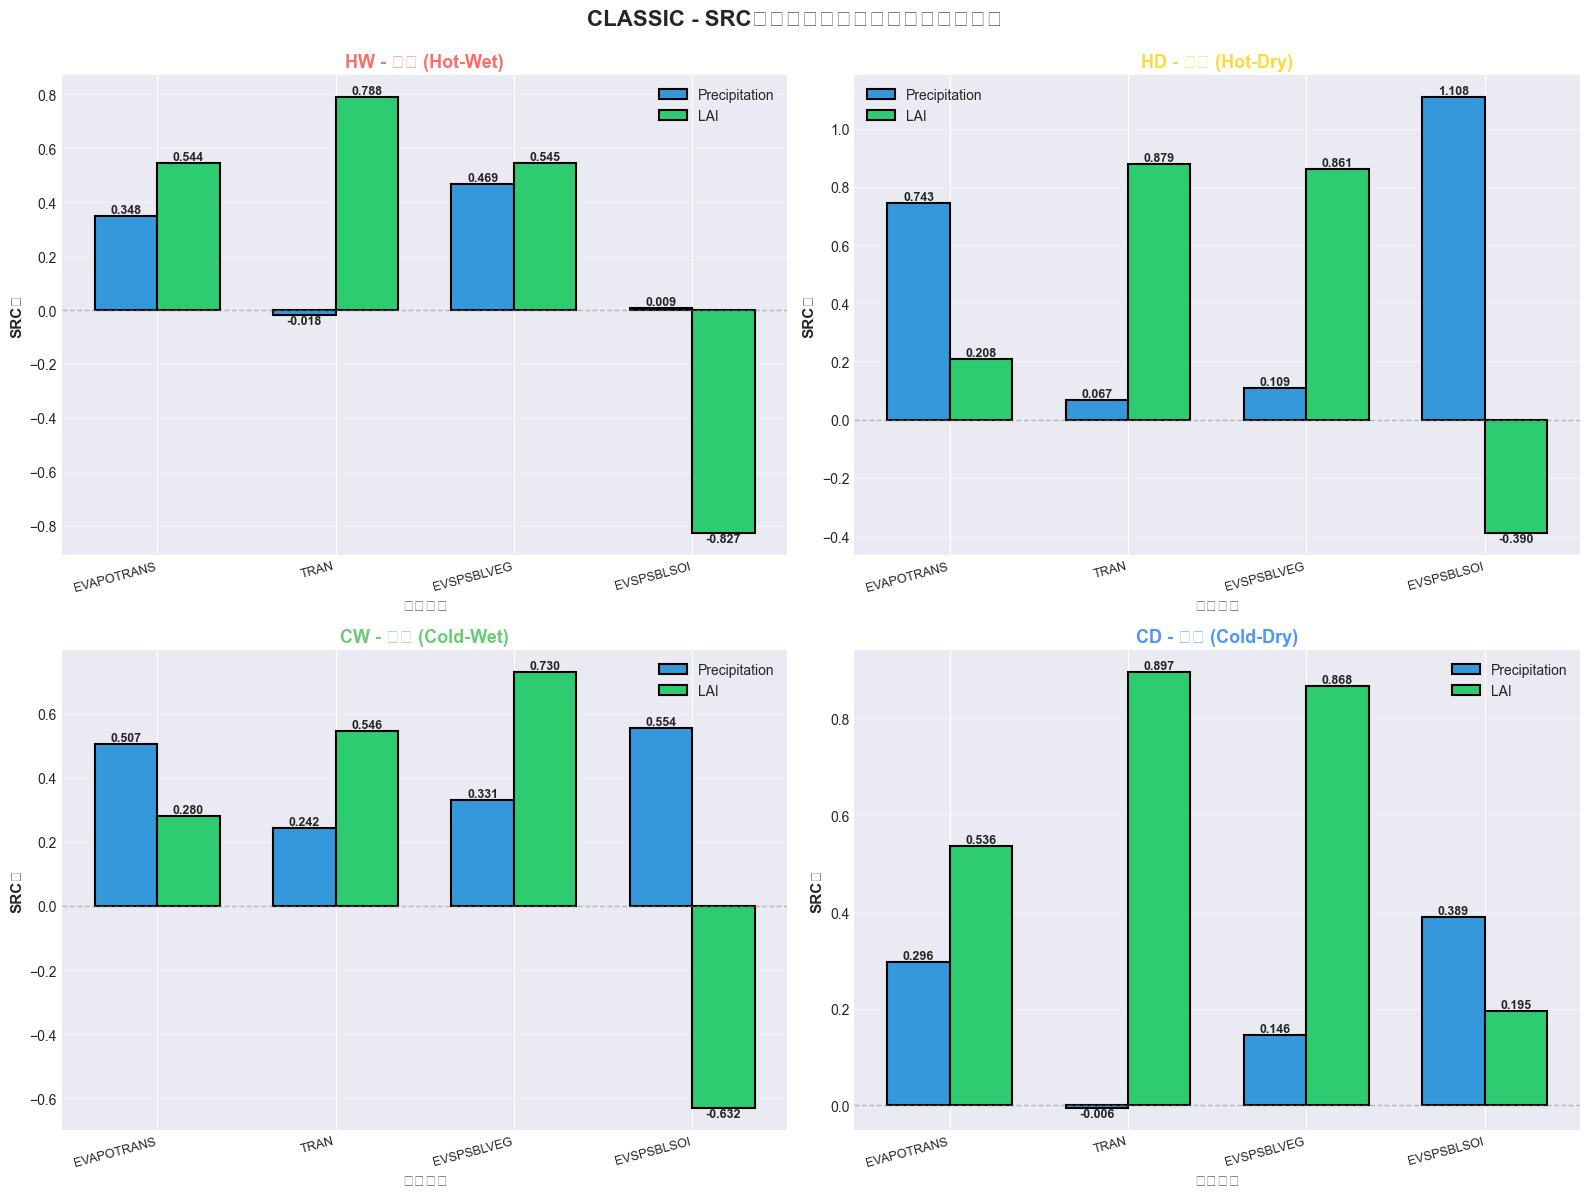

绘制LPJ-GUESS SRC - 按气候区分组...


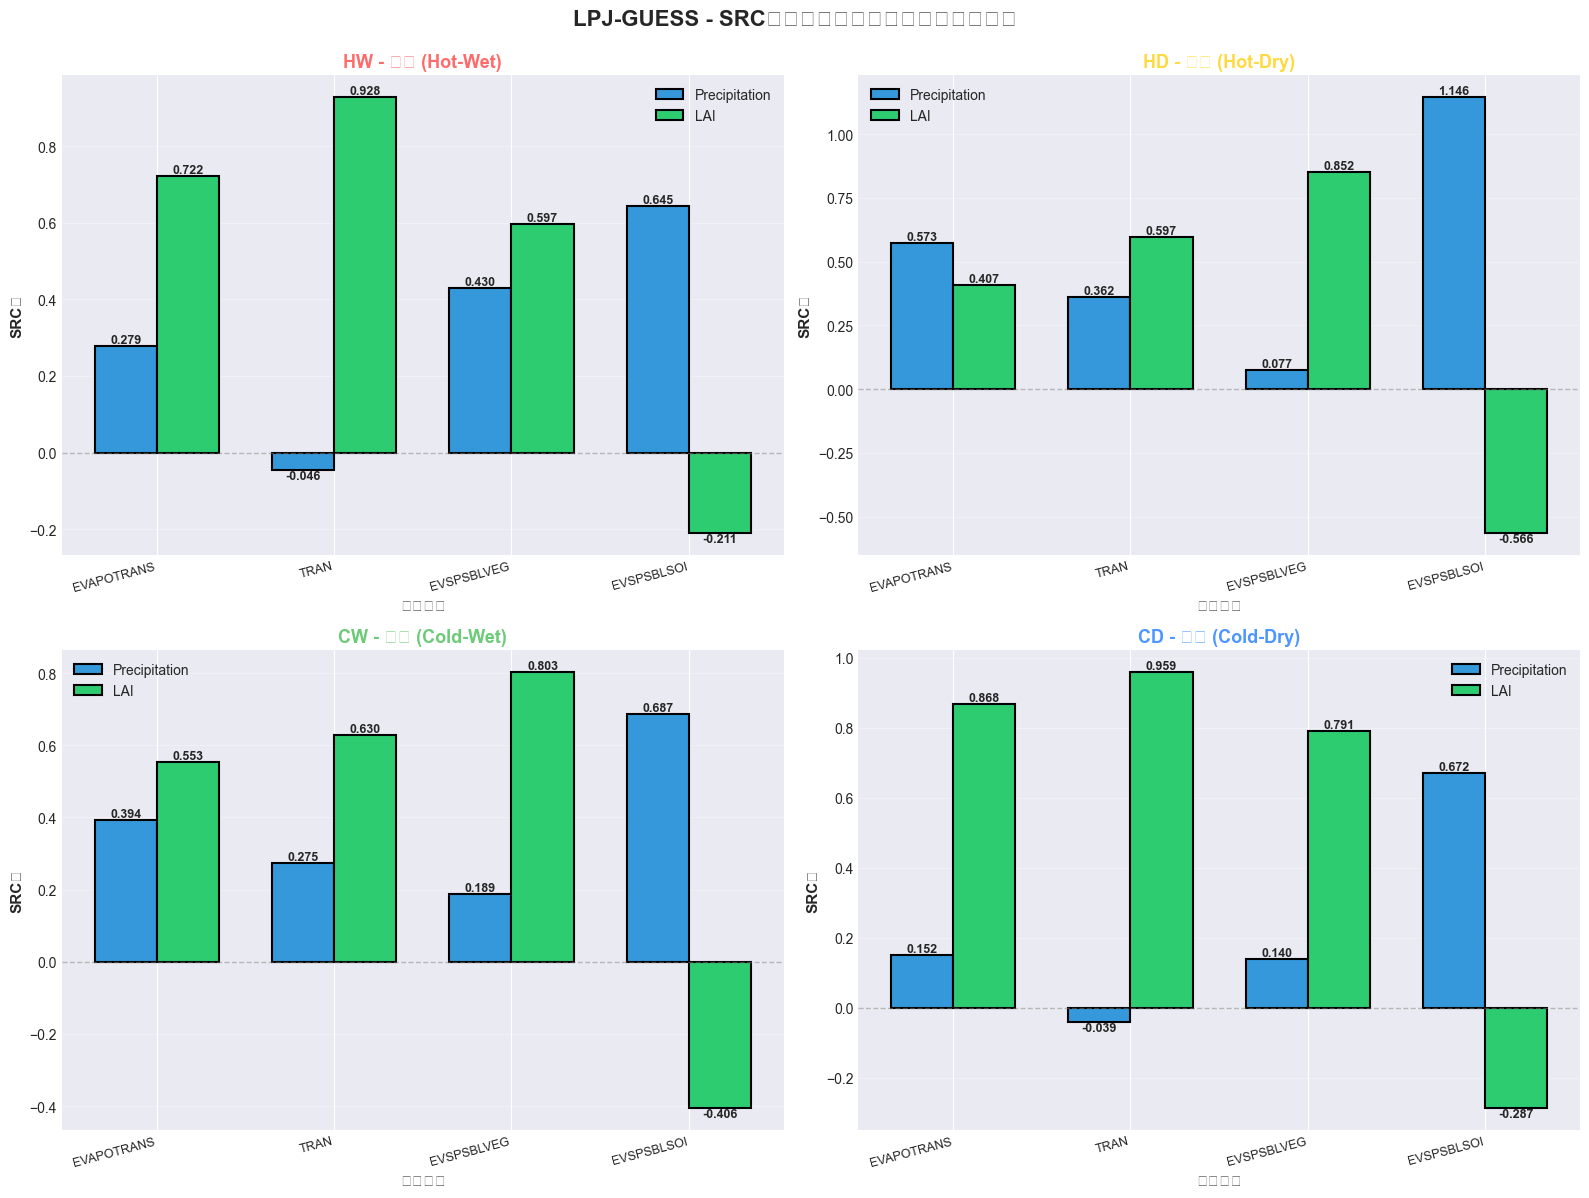

绘制CLASSIC PAWN - 按气候区分组...


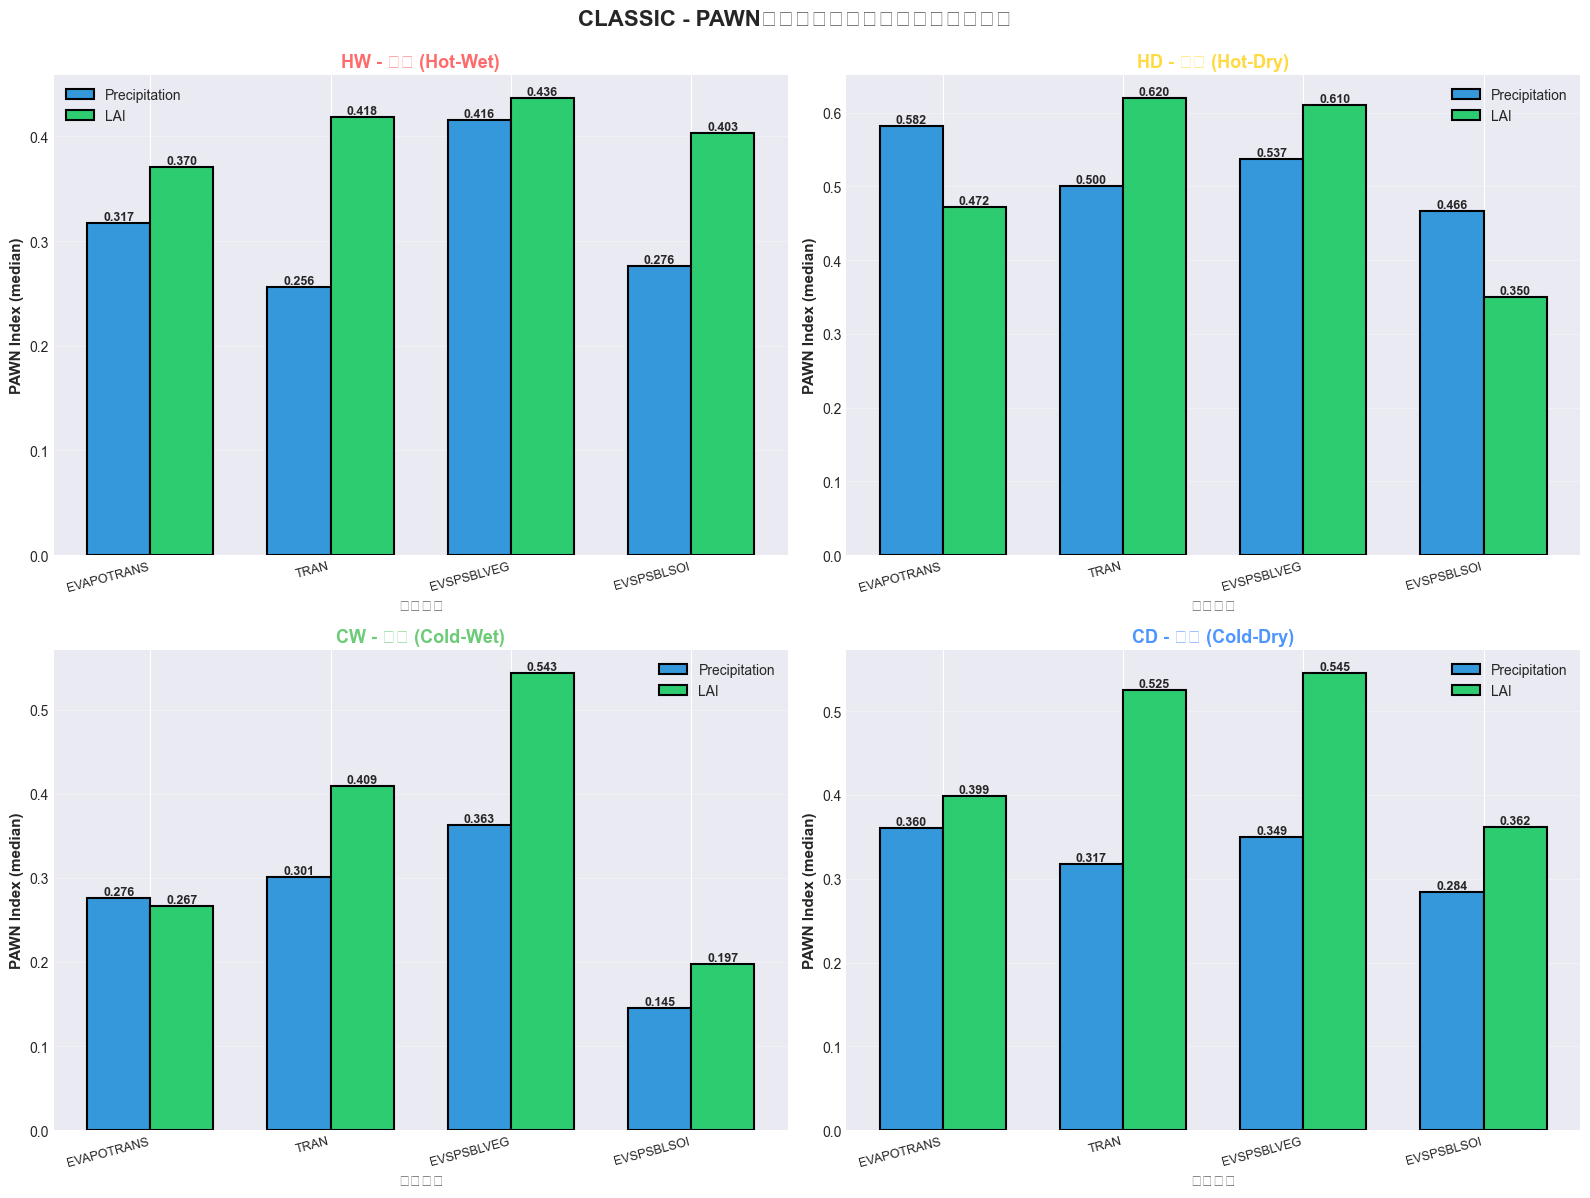

绘制LPJ-GUESS PAWN - 按气候区分组...


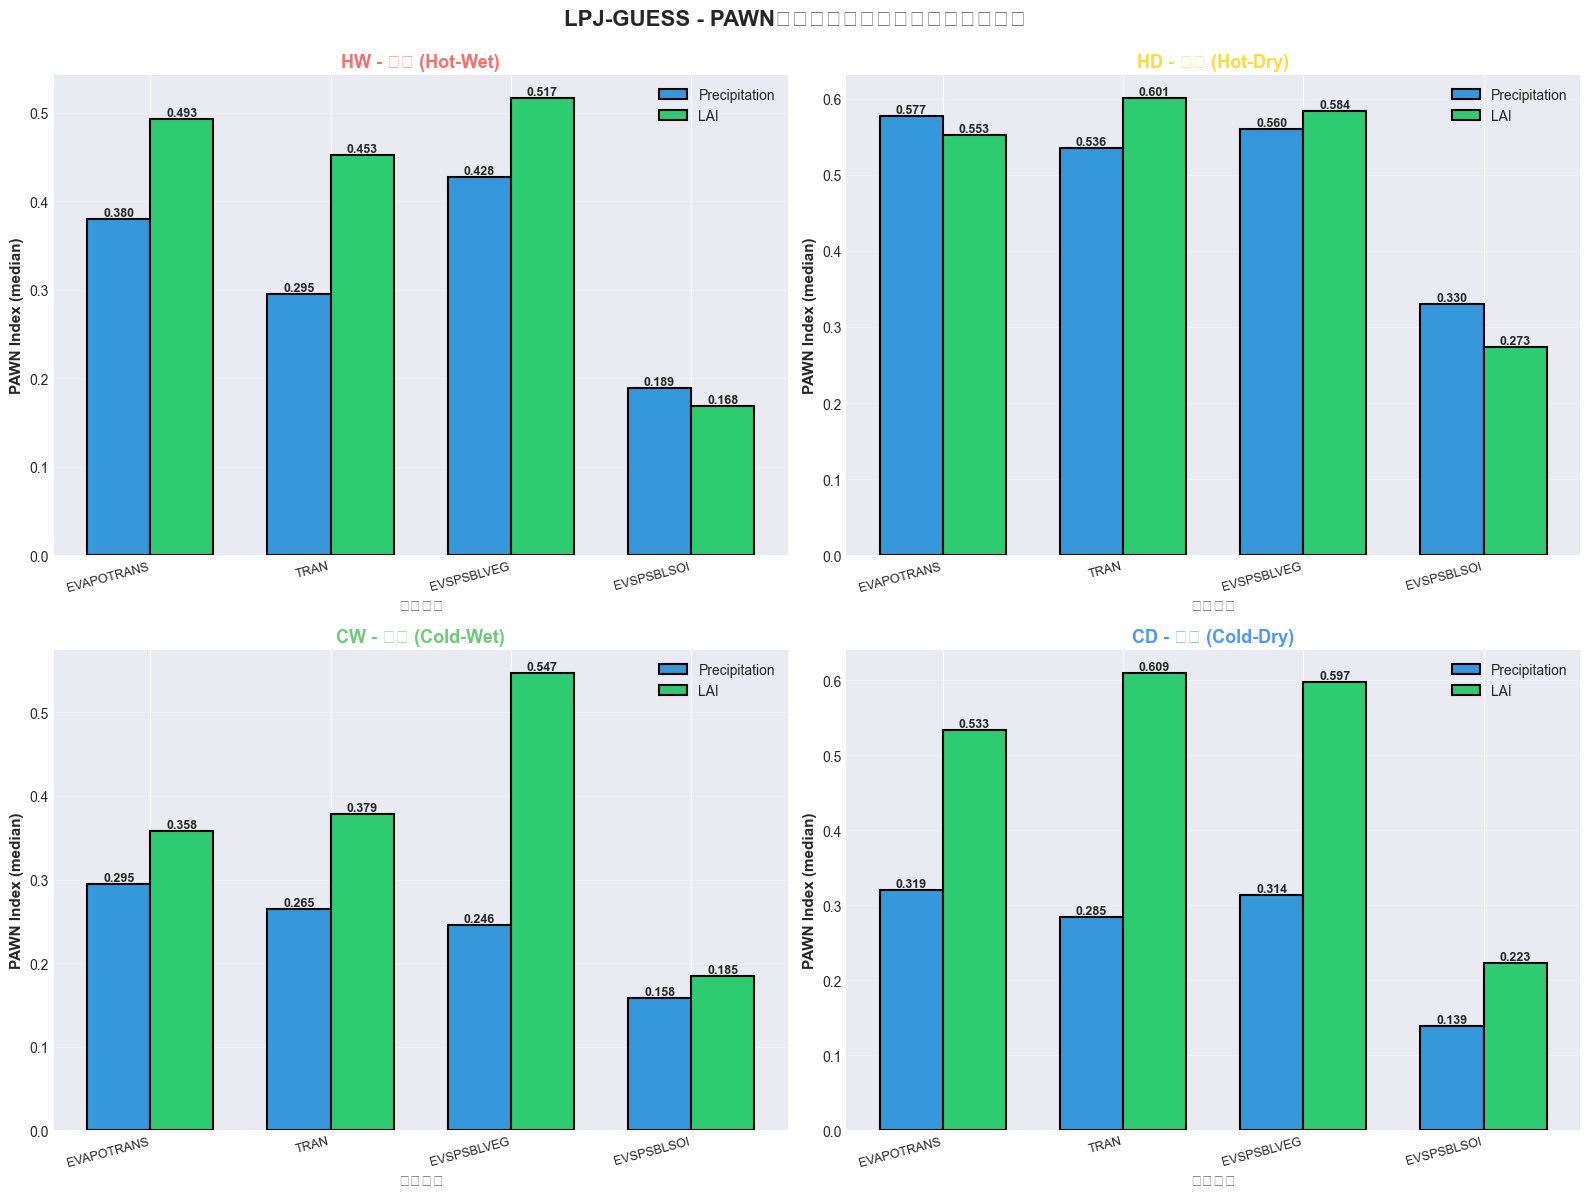

绘制CLASSIC HSIC - 按气候区分组...
绘制LPJ-GUESS HSIC - 按气候区分组...
✓ 按气候区分组的对比图已保存


In [14]:
def plot_by_zone_all_vars(df, model_name, zones, output_vars, method='SRC'):
    """
    绘制各气候区的所有输出变量对比图
    
    每个子图对应一个气候区，显示所有输出变量的敏感性指标
    
    Parameters:
    -----------
    df : DataFrame
        GSA结果数据
    model_name : str
        模型名称
    zones : list
        气候区列表
    output_vars : list
        输出变量列表
    method : str
        GSA方法 ('SRC', 'PAWN', 'HSIC')
    """
    n_zones = len(zones)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # 根据方法选择对应的列名
    if method == 'SRC':
        value_col = 'SRC'
        ylabel = 'SRC值'
        title_suffix = 'SRC分析'
    elif method == 'PAWN':
        value_col = 'PAWN_median'
        ylabel = 'PAWN Index (median)'
        title_suffix = 'PAWN分析'
    else:  # HSIC
        value_col = 'HSIC'
        ylabel = 'HSIC值'
        title_suffix = 'HSIC分析'
    
    for i, zone in enumerate(zones):
        ax = axes[i]
        
        # 筛选该气候区的数据
        zone_data = df[df['Zone'] == zone]
        
        # 准备绘图数据
        x = np.arange(len(output_vars))
        width = 0.35
        
        precip_values = []
        lai_values = []
        
        for output_var in output_vars:
            output_data = zone_data[zone_data['Output'] == output_var]
            
            p_val = output_data[output_data['Input'] == 'precipitation'][value_col].values
            l_val = output_data[output_data['Input'] == 'lai'][value_col].values
            
            precip_values.append(p_val[0] if len(p_val) > 0 else 0)
            lai_values.append(l_val[0] if len(l_val) > 0 else 0)
        
        # 绘制柱状图
        bars1 = ax.bar(x - width/2, precip_values, width, label='Precipitation',
                       color='#3498db', edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x + width/2, lai_values, width, label='LAI',
                       color='#2ecc71', edgecolor='black', linewidth=1.5)
        
        # 添加数值标签
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom' if height >= 0 else 'top',
                       fontsize=9, fontweight='bold')
        
        ax.set_xlabel('输出变量', fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
        ax.set_title(f'{zone} - {zone_names[zone]}', 
                    fontsize=13, fontweight='bold', 
                    color=zone_colors[zone])
        ax.set_xticks(x)
        ax.set_xticklabels([var.upper() for var in output_vars], 
                          fontsize=9, rotation=15, ha='right')
        
        # 对于SRC方法添加零线
        if method == 'SRC':
            ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        
        ax.legend(fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle(f'{model_name} - {title_suffix}：按气候区对比所有输出变量', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC - 按气候区分组的SRC对比
print("绘制CLASSIC SRC - 按气候区分组...")
fig1 = plot_by_zone_all_vars(classic_all_zones, 'CLASSIC', climate_zones, output_vars, method='SRC')
# fig1.savefig(output_dir / 'classic_src_by_zone_all_vars.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS - 按气候区分组的SRC对比
print("绘制LPJ-GUESS SRC - 按气候区分组...")
fig2 = plot_by_zone_all_vars(lpj_all_zones, 'LPJ-GUESS', climate_zones, output_vars, method='SRC')
# fig2.savefig(output_dir / 'lpj_src_by_zone_all_vars.png', bbox_inches='tight')
plt.show()

# 绘制CLASSIC - 按气候区分组的PAWN对比
print("绘制CLASSIC PAWN - 按气候区分组...")
fig3 = plot_by_zone_all_vars(classic_all_zones, 'CLASSIC', climate_zones, output_vars, method='PAWN')
# fig3.savefig(output_dir / 'classic_pawn_by_zone_all_vars.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS - 按气候区分组的PAWN对比
print("绘制LPJ-GUESS PAWN - 按气候区分组...")
fig4 = plot_by_zone_all_vars(lpj_all_zones, 'LPJ-GUESS', climate_zones, output_vars, method='PAWN')
# fig4.savefig(output_dir / 'lpj_pawn_by_zone_all_vars.png', bbox_inches='tight')
plt.show()

# 绘制CLASSIC - 按气候区分组的HSIC对比
print("绘制CLASSIC HSIC - 按气候区分组...")
# fig5 = plot_by_zone_all_vars(classic_all_zones, 'CLASSIC', climate_zones, output_vars, method='HSIC')
# fig5.savefig(output_dir / 'classic_hsic_by_zone_all_vars.png', bbox_inches='tight')
plt.show()

# 绘制LPJ-GUESS - 按气候区分组的HSIC对比
print("绘制LPJ-GUESS HSIC - 按气候区分组...")
# fig6 = plot_by_zone_all_vars(lpj_all_zones, 'LPJ-GUESS', climate_zones, output_vars, method='HSIC')
# fig6.savefig(output_dir / 'lpj_hsic_by_zone_all_vars.png', bbox_inches='tight')
plt.show()

print("✓ 按气候区分组的对比图已保存")

### 6.5 主导控制因子识别

In [15]:
def identify_dominant_factor(df, method='SRC'):
    """识别各气候区-输出变量组合的主导控制因子"""
    results = []
    
    for zone in df['Zone'].unique():
        zone_data = df[df['Zone'] == zone]
        
        for output_var in zone_data['Output'].unique():
            output_data = zone_data[zone_data['Output'] == output_var]
            
            if method == 'SRC':
                # 使用SRC绝对值判断
                precip_val = abs(output_data[output_data['Input'] == 'precipitation']['SRC'].values[0])
                lai_val = abs(output_data[output_data['Input'] == 'lai']['SRC'].values[0])
            elif method == 'PAWN':
                # 使用PAWN median值判断
                precip_val = output_data[output_data['Input'] == 'precipitation']['PAWN_median'].values[0]
                lai_val = output_data[output_data['Input'] == 'lai']['PAWN_median'].values[0]
            else:  # HSIC
                # 使用HSIC值判断
                precip_val = output_data[output_data['Input'] == 'precipitation']['HSIC'].values[0]
                lai_val = output_data[output_data['Input'] == 'lai']['HSIC'].values[0]
            
            dominant = 'Precipitation' if precip_val > lai_val else 'LAI'
            ratio = max(precip_val, lai_val) / (min(precip_val, lai_val) + 1e-10)
            
            results.append({
                'Zone': zone,
                'Output': output_var,
                'Dominant_Factor': dominant,
                'Precip_Value': precip_val,
                'LAI_Value': lai_val,
                'Dominance_Ratio': ratio
            })
    
    return pd.DataFrame(results)

# CLASSIC主导因子分析
print("="*80)
print("CLASSIC - 主导控制因子识别")
print("="*80)

classic_dominant_src = identify_dominant_factor(classic_all_zones, method='SRC')
print("\n基于SRC方法:")
print(classic_dominant_src.to_string(index=False))

classic_dominant_pawn = identify_dominant_factor(classic_all_zones, method='PAWN')
print("\n基于PAWN方法:")
print(classic_dominant_pawn.to_string(index=False))

# classic_dominant_hsic = identify_dominant_factor(classic_all_zones, method='HSIC')
# print("\n基于HSIC方法:")
# print(classic_dominant_hsic.to_string(index=False))

# LPJ-GUESS主导因子分析
print("\n" + "="*80)
print("LPJ-GUESS - 主导控制因子识别")
print("="*80)

lpj_dominant_src = identify_dominant_factor(lpj_all_zones, method='SRC')
print("\n基于SRC方法:")
print(lpj_dominant_src.to_string(index=False))

lpj_dominant_pawn = identify_dominant_factor(lpj_all_zones, method='PAWN')
print("\n基于PAWN方法:")
print(lpj_dominant_pawn.to_string(index=False))

# lpj_dominant_hsic = identify_dominant_factor(lpj_all_zones, method='HSIC')
# print("\n基于HSIC方法:")
# print(lpj_dominant_hsic.to_string(index=False))

CLASSIC - 主导控制因子识别

基于SRC方法:
Zone     Output Dominant_Factor  Precip_Value  LAI_Value  Dominance_Ratio
  HW evapotrans             LAI      0.348448   0.543679         1.560289
  HW       tran             LAI      0.018075   0.788426        43.620574
  HW evspsblveg             LAI      0.468544   0.545145         1.163488
  HW evspsblsoi             LAI      0.008555   0.827133        96.686190
  HD evapotrans   Precipitation      0.742948   0.208499         3.563324
  HD       tran             LAI      0.066727   0.879124        13.174974
  HD evspsblveg             LAI      0.109234   0.861012         7.882282
  HD evspsblsoi   Precipitation      1.108134   0.390396         2.838490
  CW evapotrans   Precipitation      0.506584   0.280212         1.807858
  CW       tran             LAI      0.241964   0.546217         2.257429
  CW evspsblveg             LAI      0.330894   0.729656         2.205102
  CW evspsblsoi             LAI      0.553996   0.631601         1.140082
  CD evap

## 7. 导出结果

In [16]:
# 导出GSA结果到CSV
classic_all_zones.to_csv('./importance_output/longtearm/classic_gsa_by_zone.csv', index=False)
lpj_all_zones.to_csv('./importance_output/longtearm/lpj_gsa_by_zone.csv', index=False)

# 导出主导因子识别结果
classic_dominant_src.to_csv('./importance_output/longtearm/classic_dominant_factors_src.csv', index=False)
classic_dominant_pawn.to_csv('./importance_output/longtearm/classic_dominant_factors_pawn.csv', index=False)
# classic_dominant_hsic.to_csv(output_dir / '30y_mean/classic_dominant_factors_hsic.csv', index=False)

lpj_dominant_src.to_csv('./importance_output/longtearm/lpj_dominant_factors_src.csv', index=False)
lpj_dominant_pawn.to_csv('./importance_output/longtearm/lpj_dominant_factors_pawn.csv', index=False)
# lpj_dominant_hsic.to_csv(output_dir / '30y_mean/lpj_dominant_factors_hsic.csv', index=False)

print("✓ 所有结果已导出到:", "30y_mean")
print("\n生成的文件:")
for f in sorted(output_dir.glob('*')):
    print(f"  - {f.name}")

✓ 所有结果已导出到: 30y_mean

生成的文件:
  - classic_distributions_by_zone.png
  - classic_dominant_factors_pawn.csv
  - classic_dominant_factors_src.csv
  - classic_gsa_by_zone.csv
  - classic_zone_correlations.png
  - classic_zone_distributions.png
  - lpj_distributions_by_zone.png
  - lpj_dominant_factors_pawn.csv
  - lpj_dominant_factors_src.csv
  - lpj_gsa_by_zone.csv
  - lpj_zone_correlations.png
  - lpj_zone_distributions.png


## 8. 分析总结

In [17]:
print("="*80)
print("分区GSA分析完成！")
print("="*80)

print("\n分析内容:")
print("  1. 数据探索分析（EDA）- 按4个气候区")
print("     - 基本统计")
print("     - 变量分布")
print("     - 相关性分析")

print("\n  2. 全局敏感性分析（GSA）- 按4个气候区")
print("     - SRC方法（线性参数方法）")
print("     - PAWN方法（基于KS统计量的非参数方法）")
print("     - HSIC方法（基于核方法的非参数方法）")
print("     - 主导因子识别")

print("\n气候区:")
for zone in climate_zones:
    classic_count = len(classic_df[classic_df['climate_zone'] == zone])
    lpj_count = len(lpj_df[lpj_df['climate_zone'] == zone])
    print(f"  {zone} ({zone_names[zone]}): CLASSIC={classic_count:,}, LPJ={lpj_count:,}")

print(f"\n输出目录: {output_dir}")
print("\n" + "="*80)

分区GSA分析完成！

分析内容:
  1. 数据探索分析（EDA）- 按4个气候区
     - 基本统计
     - 变量分布
     - 相关性分析

  2. 全局敏感性分析（GSA）- 按4个气候区
     - SRC方法（线性参数方法）
     - PAWN方法（基于KS统计量的非参数方法）
     - HSIC方法（基于核方法的非参数方法）
     - 主导因子识别

气候区:
  HW (热湿 (Hot-Wet)): CLASSIC=12,047, LPJ=12,149
  HD (热干 (Hot-Dry)): CLASSIC=11,072, LPJ=11,139
  CW (冷湿 (Cold-Wet)): CLASSIC=20,608, LPJ=20,732
  CD (冷干 (Cold-Dry)): CLASSIC=10,290, LPJ=9,666

输出目录: importance_output/longtearm

